# <h1 style="background-color:#4A7C59;font-family:Georgia,serif;color:#FDF6EC;font-size:36px;text-align:center;border-radius:30px 30px;padding:10px 20px;">COSC2753 - Machine Learning</h1>

<h2 align="center" style="text-align: center; font-family: Georgia,serif; font-size: 32px;">Life Expectency Dataset</h2>
<h3 align="center" style="text-align: center; font-family: Georgia,serif; font-size: 18px;">Author: Ngo Van Tai</h3>

---


# TABLE OF CONTENTS

I. [IMPORT NECESSARY LIBRARIES](#i-import-necessary-libraries)

  1. [Define some helper functions](#1-define-some-helper-functions)

II. [LOADING DATASET](#ii-loading-dataset)

III. [COLUMNS DESCRIPTION](#iii-columns-description)

IV. [EXPLORATORY DATA ANALYSIS (EDA)](#iv-exploratory-data-analysis-eda)

  1. [Initial Insight](#1-initial-insight)

  2. [Data Cleaning](#2-data-cleaning)
  
  3. [Data Analysis](#3-data-analysis)

V. [DATA PROCESSING](#v-data-preprocessing)

  1. [Feature Selection](#1-feature-selection)

  2. [Split The Dataset](#2-split-the-dataset)

  3. [Feature Scaling](#3-feature-scaling)

VI. [MODEL TRAINING](#vi-model-training)

  1. [Helper Function for Model Training](#1-helper-functions-for-model-training)

  2. [Setup cross-validation (KFold)](#2-setup-cross-validation-kfold)

  3. [Setup Result Dictionary](#3-setup-result-dictionary)

  4. [Model Selection](#4-model-selection)

VII. [BEST MODEL SELECTION](#2-best-model-selection)

  1. [Helper Function](#1-helper-function)

  2. [Best Model Selection](#2-best-model-selection)

VIII. [PREDICTION WITH BEST MODEL](#viii-prediction-with-best-model)

# I. IMPORT NECESSARY LIBRARIES


In [75]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import math

import joblib
import os

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Model preprocessing and evaluation
from scipy.stats.mstats import winsorize
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
)

## 1) Define some helper functions


### 1.1) Print Header

In [76]:
def print_header(content, padding=10, width=None, tabs=False):
    """
    Prints a header wrapped inside a box.

    Parameters:
    - content: Text to display as header (automatically uppercase)
    - padding: Spaces on each side of the content inside the box
    - width: Optional fixed width for the entire box. If None, adjusts to content size.
    - tabs: If true, adds the spacing `\t`to center of the box
    """
    content = content.upper()
    inner_width = len(content) + (padding * 2)
    box_width = width if width and width > inner_width else inner_width

    top_bottom = "+" + "-" * (box_width + 2) + "+"
    padded_content = "| " + content.center(box_width) + " |"
    prefix = "\t" * 3 if tabs else ""

    print(f"{prefix}{top_bottom}")
    print(f"{prefix}{padded_content}")
    print(f"{prefix}{top_bottom}")

### 1.2) Create Regression Plot

In [77]:
def create_regression_plot(
    df,
    x,
    y,
    title=None,
    height=6,
    aspect=1.2,
    rows=None,
    cols=3,
    figsize=(15, 15),
    multi=False,
):
    """
    Create regression plots using seaborn's lmplot.

    Parameters:
    - df: DataFrame containing the data
    - x: string or list, column name(s) for x-axis. If list and multi=True, creates multiple plots
    - y: string, column name for y-axis (target variable). Required if multi=True
    - title: string or list, title(s) for the plot(s)
    - height: int, height of each plot in inches
    - aspect: float, aspect ratio of each plot
    - rows: int, number of rows for grid layout (calculated automatically if None)
    - cols: int, number of columns for grid layout
    - figsize: tuple, size of the figure for multiple plots
    - multi: bool, whether to create multiple plots (one per x variable)

    Returns:
    - The created plot(s) object for further customization
    """

    if not multi:
        g = sns.lmplot(
            data=df,
            x=x,
            y=y,
            height=height,
            aspect=aspect,
            line_kws={"color": "red"},
            scatter_kws={"alpha": 0.5},
        )
        # Add title and labels
        if title:
            plt.title(title)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.grid(True)
        return g
    else:
        if y is None:
            rows = len(x) + cols - 1

        fig = plt.figure(figsize=figsize)

        # Create titles list if only one title is provided
        if isinstance(title, str):
            titles = [f"{x_col} vs {y}" for x_col in x]
        elif isinstance(title, list) and len(title) == len(x):
            titles = title
        else:
            titles = [None] * len(x)

        for i, x_col in enumerate(x):
            plt.subplot(rows, cols, i + 1)

            sns.regplot(
                x=df[x_col],
                y=df[y],
                line_kws={"color": "red"},
                scatter_kws={"alpha": 0.5},
            )

            if titles[i]:
                plt.title(titles[i])
            plt.xlabel(x_col)
            plt.ylabel(y)
            plt.grid(True)

        plt.tight_layout()
        return fig

### 1.3) Create Boxplot Visualization

In [78]:
def create_boxplots(
    df, cols=None, figsize=(12, 12), n_cols=5, n_rows=5, title=None, horizontal=False
):
    """
    Create a grid of boxplots for dataframe columns.

    Parameters:
    df : pandas DataFrame
        The dataframe containing the data to plot
    cols : list
        List of column names to plot. If None, all columns are plotted.
    figsize : tuple
        Figure size (width, height) in inches
    n_cols : int
        Number of columns in the grid
    n_rows : int
        Number of rows in the grid
    title : str
        Title for the figure
    horizontal: bool, default False
        If True, creates horizontal boxplot

    Returns:
    fig, axs : matplotlib figure and axes objects
    """
    # If no columns specified, use all columns
    if cols is None:
        cols = df.columns

    # Create figure and axes
    fig, axs = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=figsize)
    axs = axs.flatten()

    # Create boxplots
    for i, col in enumerate(cols):
        if i < len(axs):
            if horizontal:
                sns.boxplot(x=col, data=df, ax=axs[i], orient="h")
                axs[i].set_ylabel("")
                axs[i].set_xlabel("")
                axs[i].set_title(col, fontsize=10)
            else:
                sns.boxplot(y=col, data=df, ax=axs[i])
                axs[i].set_xlabel(col)
                axs[i].set_title(col, fontsize=10)
                axs[i].set_ylabel("")

    # Remove any empty subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

    # Add title if provided
    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    return fig, axs

### 1.4) Create Correlation Matrix

In [79]:
def plot_correlation_matrix(
    df, title="Correlation Matrix", figsize=(20, 12), cmap="coolwarm", fmt=".2f"
):
    """
    Plots a correlation matrix heatmap for a given DataFrame.

    Parameters:
    df : pandas DataFrame
        The DataFrame for which the correlation matrix is to be plotted.
    title : str, default "Correlation Matrix"
        The title of the heatmap.
    figsize : tuple, default (20, 12)
        The size of the figure.
    cmap : str, default "coolwarm"
        The colormap to use for the heatmap.
    fmt : str, default ".2f"
        String formatting for the correlation values.
    """
    plt.figure(figsize=figsize)

    # Create a mask to hide the upper triangle of the correlation matrix
    mask = np.triu(np.ones_like(df.corr(), dtype=bool))

    # Plot the heatmap
    sns.heatmap(df.corr(), annot=True, cmap=cmap, fmt=fmt, mask=mask)

    # Add title
    plt.title(title)
    plt.show()

### 1.5) Create Histogram Visualization

In [80]:
def plot_data_distributions(
    df, bins=10, kde=True, n_cols=4, figsize=(16, 12), title=None
):
    """
    Plots histograms with optional KDE for all columns in a DataFrame.

    Parameters:
    df : pandas DataFrame
        The DataFrame containing the data to plot.
    bins : int, default 10
        Number of bins for the histograms.
    kde : bool, default True
        Whether to include a KDE (Kernel Density Estimate) curve.
    n_cols : int, default 4
        Number of columns in the grid layout.
    figsize : tuple, default (16, 12)
        Size of the entire figure.
    title : str, optional
        Title for the entire figure.
    """
    n_cols = min(
        n_cols, len(df.columns)
    )  # Ensure n_cols doesn't exceed the number of columns
    n_rows = math.ceil(len(df.columns) / n_cols)

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    # Plot each column
    for i, column in enumerate(df.columns):
        sns.histplot(df[column], bins=bins, kde=kde, ax=axes[i])
        axes[i].set_title(f"Data Distribution of {column}")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Frequency")

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add a title for the entire figure if provided
    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

# II. LOADING DATASET


In [81]:
df = pd.read_csv("./inputs/train.csv")

# III. COLUMNS DESCRIPTION

The table below provides a general description of each column, including the target variable `TARGET-LifeExpectancy`, which represents life expectancy in years. For detailed information, please refer to the [readme.txt](./inputs/readme.txt) file.


| Column Name                  | Description                                                                          |
| ---------------------------- | ------------------------------------------------------------------------------------ |
| ID                           | Row index (not an attribute)                                                         |
| TARGET-LifeExpectancy        | Life Expectancy in age (years)                                                       |
| Country                      | Index of Country                                                                     |
| Year                         | Year                                                                                 |
| Status                       | Developed or Developing status (1 = Developed, 0 = Developing)                       |
| AdultMortality               | Adult Mortality Rates (15-60 yrs) per 1000 population (both sexes)                   |
| AdultMortality-Female        | Adult Mortality Rates for Females per 1000 population                                |
| AdultMortality-Male          | Adult Mortality Rates for Males per 1000 population                                  |
| SLS                          | Total number of life years lived by people who died prematurely, per 1000 population |
| Alcohol                      | Alcohol consumption (litres per capita , age 15+)                                     |
| PercentageExpenditure        | Health expenditure as % of GDP per capita                                            |
| Measles                      | Measles cases per 1000 population                                                    |
| BMI                          | Average Body Mass Index                                                              |
| Under5LS                     | Number of under-five life span per 1000 population                                   |
| Polio                        | Polio immunization coverage among 1-year-olds (%)                                    |
| TotalExpenditure             | Government expenditure on health as % of total government expenditure                |
| Diphtheria                   | DTP3 immunization coverage among 1-year-olds (%)                                     |
| HIV-AIDS                     | Life span impact (0–4 years) per 1000 from HIV/AIDS                                  |
| GDP                          | Gross Domestic Product per capita (USD)                                              |
| Population                   | Country population                                                                   |
| Thinness1-19years            | Prevalence of thinness (age 10–19) %                                                 |
| Thinness5-9years             | Prevalence of thinness (age 5–9) %                                                   |
| IncomeCompositionOfResources | Human Development Index income composition (0 to 1 index)                            |
| Schooling                    | Indicate overall education levels in a country                                       |


# IV. EXPLORATORY DATA ANALYSIS (EDA)


## 1) Initial Insight

### Overview of the raw dataset


In [82]:
print_header("example data", tabs=True, padding=15)
df

			+--------------------------------------------+
			|                EXAMPLE DATA                |
			+--------------------------------------------+


,ID,TARGET_LifeExpectancy,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness1-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
0,1,67.1,146,2017,0,263.0,262,264,62,0.01,...,6.0,8.16,65.0,0.1,654.37,33736494.0,17.2,17.3,0.479,3.178050
1,2,59.8,146,2016,0,271.0,278,264,64,0.01,...,58.0,8.18,62.0,0.1,686.22,327582.0,17.5,17.5,0.476,3.162278
2,3,57.6,146,2015,0,268.0,246,290,66,0.01,...,62.0,8.13,64.0,0.1,707.55,31731688.0,17.7,17.7,0.470,3.146427
3,4,55.5,146,2014,0,272.0,248,296,69,0.01,...,67.0,8.52,67.0,0.1,750.35,3696958.0,17.9,18.0,0.463,3.130495
4,5,57.7,146,2013,0,275.0,278,272,71,0.01,...,68.0,7.87,68.0,0.1,71.16,2978599.0,18.2,18.2,0.454,3.082207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,2067,47.7,61,2006,0,578.0,596,560,36,2.46,...,84.0,7.33,83.0,17.6,59.67,11731746.0,7.2,7.1,0.456,3.240370
2067,2068,46.0,61,2005,0,64.0,66,62,39,2.33,...,85.0,8.18,83.0,18.2,480.66,11421984.0,7.3,7.2,0.443,3.193744
2068,2069,46.2,61,2004,0,69.0,70,68,41,2.44,...,85.0,6.93,84.0,18.4,422.39,NaN,7.4,7.3,0.433,3.162278
2069,2070,47.1,61,2003,0,611.0,574,648,43,2.61,...,86.0,6.56,85.0,18.6,423.67,1824125.0,7.4,7.4,0.424,3.130495


### Dataset Dimensions

The Life Expectancy dataset consists of **2,071 observations** across **24 variables** (including the target variable).


In [83]:
print_header("data shape")
print("Number of Rows: ", df.shape[0])
print("Number of Features: ", df.shape[1])

+--------------------------------+
|           DATA SHAPE           |
+--------------------------------+
Number of Rows:  2071
Number of Features:  24


### Column Overview

Generally, all of the dataset's features are of the numerical types (`int64` or `float64`). This shows that the data contains either continuous values (e.g., `GDP`, `BMI`) or discrete numeric categories (e.g., `Status`, `Country`).

Although these columns are all numerical type, additional inspection of the actual values is necessary to determine whether some columns (like `Status` or `Country`) should be handled as categorical variables instead of continuous ones.

Furthermore, I notice that the column name of `Thinness1-19years` is unclear, because it represents the thinness for individuals aged 10-19 years. So, to improve clarity, I will rename it to `Thinness10-19years`


In [84]:
print_header("columns overview", tabs=True)
df.info()

			+--------------------------------------+
			|           COLUMNS OVERVIEW           |
			+--------------------------------------+
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            2071 non-null   int64  
 1   TARGET_LifeExpectancy         2071 non-null   float64
 2   Country                       2071 non-null   int64  
 3   Year                          2071 non-null   int64  
 4   Status                        2071 non-null   int64  
 5   AdultMortality                2070 non-null   float64
 6   AdultMortality-Male           2071 non-null   int64  
 7   AdultMortality-Female         2071 non-null   int64  
 8   SLS                           2071 non-null   int64  
 9   Alcohol                       2067 non-null   float64
 10  PercentageExpenditure         2062 non-null   fl

In [85]:
print_header("change column name")
df.rename(columns={"Thinness1-19years": "Thinness10-19years"}, inplace=True)

df[["Thinness10-19years"]]

+----------------------------------------+
|           CHANGE COLUMN NAME           |
+----------------------------------------+


,Thinness10-19years
0,17.2
1,17.5
2,17.7
3,17.9
4,18.2
...,...
2066,7.2
2067,7.3
2068,7.4
2069,7.4


### Remove `ID` column

As described in the column description table, the column `ID` is a unique identifier and not the real attribute. Since it does not contribute to the predictive modeling or provide any information, I will drop it from the dataset.


In [86]:
print_header("drop column `id`", tabs=True)
df = df.drop("ID", axis=1, errors="ignore")
print("New data shape:", df.shape)

			+--------------------------------------+
			|           DROP COLUMN `ID`           |
			+--------------------------------------+
New data shape: (2071, 23)


### Statistical Summary of the Dataset

In [87]:
print_header("Dataset overview", tabs=True)
df.describe() 

			+--------------------------------------+
			|           DATASET OVERVIEW           |
			+--------------------------------------+


,TARGET_LifeExpectancy,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
count,2071.000000,2071.000000,2071.000000,2071.000000,2070.00000,2071.000000,2071.000000,2071.000000,2067.000000,2062.000000,...,2070.000000,2061.000000,2071.000000,2068.000000,2062.000000,2.063000e+03,2070.000000,2070.000000,2066.000000,2064.000000
mean,69.274505,95.360212,2009.518590,0.185418,162.82029,161.908257,163.759536,33.079672,4.693009,764.429066,...,82.720773,5.881827,82.753259,1.632544,7304.336600,1.205231e+07,4.939034,4.977971,0.609866,3.372332
std,9.482281,54.861641,4.614147,0.388730,118.89928,119.442235,118.800292,135.832868,4.205270,2083.501026,...,23.192604,2.557347,23.130969,4.784991,15179.036764,6.403752e+07,4.697848,4.786593,0.216610,0.590975
min,37.300000,0.000000,2002.000000,0.000000,1.00000,0.000000,2.000000,0.000000,0.010000,0.000000,...,3.000000,0.370000,2.000000,0.100000,1.880000,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,63.000000,50.000000,2006.000000,0.000000,74.00000,74.000000,74.000000,0.000000,0.615000,5.688828,...,77.000000,4.180000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942
50%,71.200000,94.000000,2010.000000,0.000000,144.00000,142.000000,144.000000,3.000000,3.820000,68.943329,...,93.000000,5.640000,93.000000,0.100000,1390.315000,6.477440e+05,3.200000,3.300000,0.655500,3.449638
75%,76.000000,144.000000,2014.000000,0.000000,228.00000,228.000000,230.000000,22.000000,7.840000,429.434148,...,97.000000,7.430000,97.000000,0.800000,5746.287500,5.364814e+06,7.375000,7.400000,0.770000,3.741657
max,92.700000,192.000000,2017.000000,1.000000,699.00000,704.000000,722.000000,1800.000000,17.870000,19479.911610,...,99.000000,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,27.700000,28.600000,0.948000,4.381780


### Checking for Missing Values and Duplicated Values

In the dataset, there are a few rows that have missing data but do not have duplicated data. I will handle this problem in the next step.


In [88]:
print_header("Total of missing data")

df.isnull().sum()

+-------------------------------------------+
|           TOTAL OF MISSING DATA           |
+-------------------------------------------+


TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   1
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          4
PercentageExpenditure            9
Measles                          1
BMI                              8
Under5LS                         1
Polio                            1
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              9
Population                       8
Thinness10-19years               1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64

In [89]:
print_header("check duplicated data", tabs=False)
df.duplicated().any()

+-------------------------------------------+
|           CHECK DUPLICATED DATA           |
+-------------------------------------------+


False

## 2) Data Cleaning

### 2.1) Missing Values

#### Missing Value Detection

Upon close inspection of the data frame, there are many anomalies and potential data issues were identified. These problems may indicate inaccurate in data collection or unrealistic values that require further investigation and handling: 

- `AdultMortality`, `AdultMortality-Male`, `AdultMortality-Female`: The minimum values for these columns are 1, 0 ,2 respectively. Such values may cause by the errors or inconsistencies in data collection.

- `SLS` and `Under5LS`:  These features contain 0 values, which could represent missing data where 0 was used as a placeholder.

- `BMI`: The `BMI` values in the dataset range from 1 to 87.3, which are highly unrealistic. Generally, `BMI` below 10 or above 50 is considered extremely rare. 

- `GDP` and `Population`: These columns contain extremely small values (e.g., GDP = 1.88, Population = 34). While unrealistic, these are not treated as missing but will be considered during the outlier treatment process.

In [90]:
df.describe()

,TARGET_LifeExpectancy,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
count,2071.000000,2071.000000,2071.000000,2071.000000,2070.00000,2071.000000,2071.000000,2071.000000,2067.000000,2062.000000,...,2070.000000,2061.000000,2071.000000,2068.000000,2062.000000,2.063000e+03,2070.000000,2070.000000,2066.000000,2064.000000
mean,69.274505,95.360212,2009.518590,0.185418,162.82029,161.908257,163.759536,33.079672,4.693009,764.429066,...,82.720773,5.881827,82.753259,1.632544,7304.336600,1.205231e+07,4.939034,4.977971,0.609866,3.372332
std,9.482281,54.861641,4.614147,0.388730,118.89928,119.442235,118.800292,135.832868,4.205270,2083.501026,...,23.192604,2.557347,23.130969,4.784991,15179.036764,6.403752e+07,4.697848,4.786593,0.216610,0.590975
min,37.300000,0.000000,2002.000000,0.000000,1.00000,0.000000,2.000000,0.000000,0.010000,0.000000,...,3.000000,0.370000,2.000000,0.100000,1.880000,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,63.000000,50.000000,2006.000000,0.000000,74.00000,74.000000,74.000000,0.000000,0.615000,5.688828,...,77.000000,4.180000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942
50%,71.200000,94.000000,2010.000000,0.000000,144.00000,142.000000,144.000000,3.000000,3.820000,68.943329,...,93.000000,5.640000,93.000000,0.100000,1390.315000,6.477440e+05,3.200000,3.300000,0.655500,3.449638
75%,76.000000,144.000000,2014.000000,0.000000,228.00000,228.000000,230.000000,22.000000,7.840000,429.434148,...,97.000000,7.430000,97.000000,0.800000,5746.287500,5.364814e+06,7.375000,7.400000,0.770000,3.741657
max,92.700000,192.000000,2017.000000,1.000000,699.00000,704.000000,722.000000,1800.000000,17.870000,19479.911610,...,99.000000,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,27.700000,28.600000,0.948000,4.381780


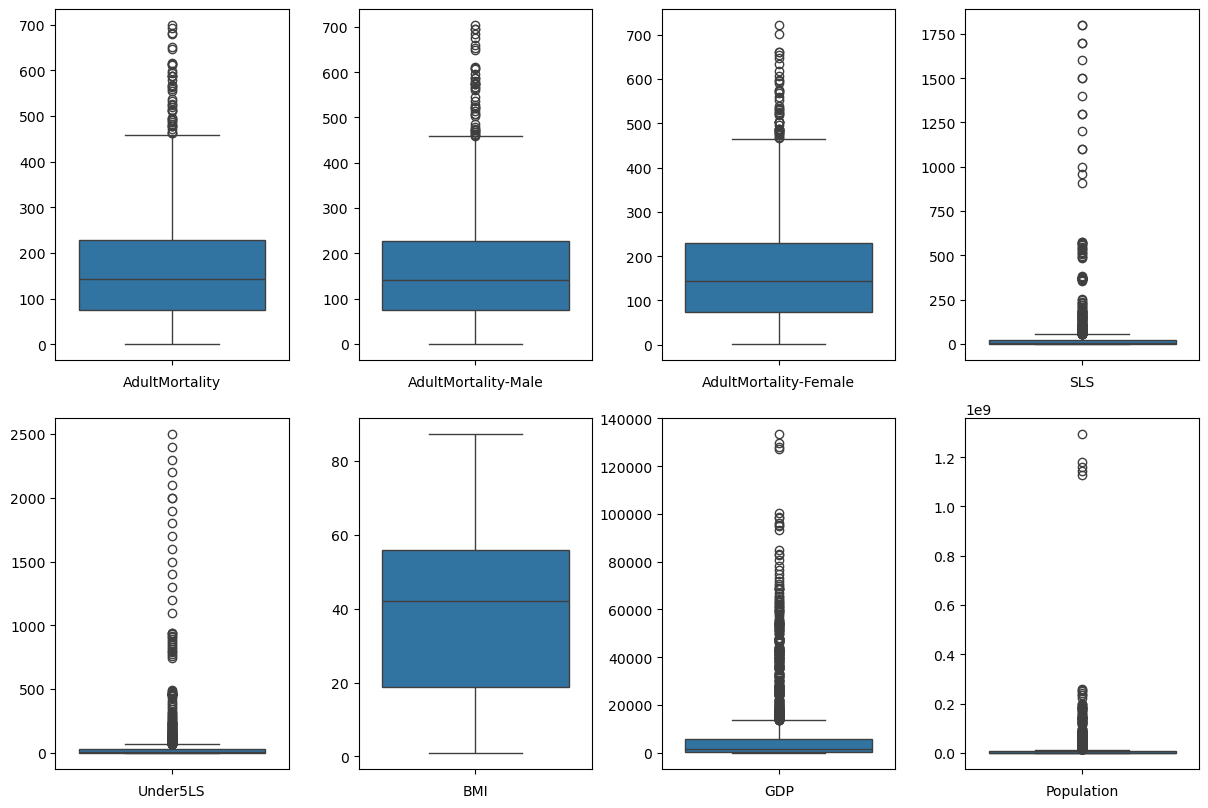

In [91]:
suspected_cols = [
    "AdultMortality",
    "AdultMortality-Male",
    "AdultMortality-Female",
    "SLS",
    "Under5LS",
    "BMI",
    "GDP",
    "Population",
]

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(12, 8))
axs = axs.flatten()

for index, col in enumerate(suspected_cols):
    sns.boxplot(y=col, data=df, ax=axs[index])
    axs[index].set_xlabel(col)
    axs[index].set_title("")
    axs[index].set_ylabel("")


plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.show()

Based on statistical analysis, I identified and addressed the problems in the dataset:

1. **Adult Mortality Rate for both sexes**: I will replace all the values that are below the 5th percentile with NaN.

2. **SLS and Under5LS**: Zero values were treated as missing data (NaN)

3. **BMI Values**: Body Mass Index values outside the range of 10-50 will be treated as missing data (NaN)

In [92]:
mortality_cols = ["AdultMortality", "AdultMortality-Male", "AdultMortality-Female"]

# Clean each mortality column
for col in mortality_cols:
    mortality_5_percentile = np.percentile(df[col].dropna(), 5)

    df[col] = df.apply(
        lambda x: np.nan if x[col] < mortality_5_percentile else x[col], axis=1
    )


# Replace 0 with NaN
df["SLS"] = df["SLS"].replace(0, np.nan)
df["Under5LS"] = df["Under5LS"].replace(0, np.nan)

# Replace BMI < 10 and BMI > 50 with NaN
df["BMI"] = df.apply(
    lambda x: np.nan if (x["BMI"] < 10 or x["BMI"] > 50) else x["BMI"], axis=1
)

In [93]:
# Check missing values again
df.isna().sum()

TARGET_LifeExpectancy             0
Country                           0
Year                              0
Status                            0
AdultMortality                  103
AdultMortality-Male              92
AdultMortality-Female            90
SLS                             577
Alcohol                           4
PercentageExpenditure             9
Measles                           1
BMI                             993
Under5LS                        532
Polio                             1
TotalExpenditure                 10
Diphtheria                        0
HIV-AIDS                          3
GDP                               9
Population                        8
Thinness10-19years                1
Thinness5-9years                  1
IncomeCompositionOfResources      5
Schooling                         7
dtype: int64

In [94]:
def null_inspect():
    """
    Inspect and display the number and percentage of missing values in each column.
    """
    
    print_header("null inspect", padding=22)
    print("")

    cols = list(df.columns)
    null_cols_cnt = 0

    # print columns name
    print(f"{'Column':<30} {'Null Count':>12} {'% Missing':>12}")
    print("-" * 60)

    for col in cols:
        null_cnt = df[col].isnull().sum()
        total_cnt = df[col].isnull().count()
        rate = round(null_cnt / total_cnt * 100, 2)

        if null_cnt > 0:
            null_cols_cnt += 1
            print(f"{col:<30} {null_cnt:>12} {rate:>11.2f}%")

    null_rate_cols = round(null_cols_cnt / len(cols) * 100, 2)
    print("-" * 60)
    print(
        f"In total: there are {len(cols)} columns, {null_cols_cnt} contain nulls "
        f"({null_rate_cols}% of all columns)"
    )


null_inspect()

+----------------------------------------------------------+
|                       NULL INSPECT                       |
+----------------------------------------------------------+

Column                           Null Count    % Missing
------------------------------------------------------------
AdultMortality                          103        4.97%
AdultMortality-Male                      92        4.44%
AdultMortality-Female                    90        4.35%
SLS                                     577       27.86%
Alcohol                                   4        0.19%
PercentageExpenditure                     9        0.43%
Measles                                   1        0.05%
BMI                                     993       47.95%
Under5LS                                532       25.69%
Polio                                     1        0.05%
TotalExpenditure                         10        0.48%
HIV-AIDS                                  3        0.14%
GDP           

#### Handling Missing Values

After applying outlier detection and removal, the `BMI` column now contains missing values in almost 48% of its column. This high proportion of missing values significantly reduces the reliability of the feature, and any imputation would introduce substantial bias due to the lack of valid data. 

The BMI variable's high percentage of missing data may result in inaccurate imputation and distorted model results, hence, it was excluded in the dataset to preserve the validity of the analysis.

In [95]:
df.drop("BMI", axis=1, inplace=True, errors="ignore")

In this dataset, to handle the missing values, imputing the missing values with the **mean** grouped by `Country` may seem appropriate. However, it is better to group by `Year` as it can reflects the global trends that evolve from year to year. For example, several features such as `AdultMortality`, `Alcohol consumption` are **time-sensitive**. By imputing using the mean of each year, we can get the temporal nature of these variables.

In [96]:
imputer = SimpleImputer(strategy="mean")

imputed_data = []
years = df["Year"].unique()

for year in years:
    data = df[df["Year"] == year].copy()

    # Apply imputer
    imputed_arr = imputer.fit_transform(data)
    imputed_df = pd.DataFrame(imputed_arr, columns=data.columns, index=data.index)

    imputed_data.append(imputed_df)

# Combine all year-wise imputed data
df = pd.concat(imputed_data)

null_inspect()

+----------------------------------------------------------+
|                       NULL INSPECT                       |
+----------------------------------------------------------+

Column                           Null Count    % Missing
------------------------------------------------------------
------------------------------------------------------------
In total: there are 22 columns, 0 contain nulls (0.0% of all columns)


### 2.2) Outliers

#### Outliers Detection

Look at the boxplot below, we can easily see that there're many outliers across multiple features - including the target variable `TARGET_LifeExpectancy`. This suggests that the further outliers detection and treatment will be necessary before modeling.

There are several common methods to detect outliers:

1. **Z-score Method**
- Assumes a normal distribution
- Flags values with a Z-score (standard deviations from the mean) above a certain threshold (commonly > 3 or < -3).
- However, this is not ideal for skewed distribution

2. **IQR (Tukey's Method)**
- Based on the **interquartile range**
- Values outside `Q1 - 1.5 * IQR` or `Q3 + 1.5 * IQR` are considered outliers
- Works well with **non-normal** and **skewed** distributions.

3. **Isolation Forest / LOF (Local Outlier Factor)**
- Machine learning-based methods for detecting outliers in high-dimensional datasets.
- Better for large, complex datasets but may be overkill for basic EDA.

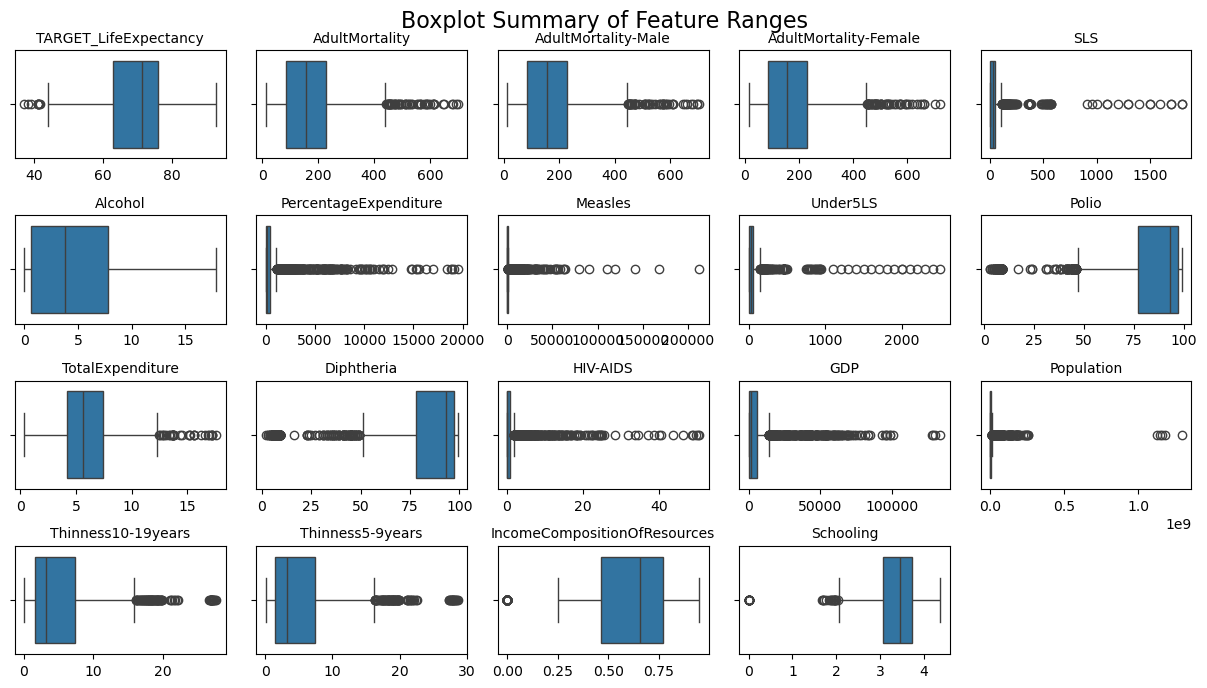

In [97]:
# take the 1st and 4th col to the end (start from AdultMortality). Skip country, year, status
inspected_cols = [df.columns[0]] + list(df.columns[4:])

fig, axs = create_boxplots(
    df,
    cols=inspected_cols,
    n_rows=5,
    figsize=(12, 8),
    horizontal=True,
    title="Boxplot Summary of Feature Ranges",
)
plt.show()

Although there are many good strategies for outlier detection, in this dataset, I applied the **Tukey's IQR method** because of its significant benefits:
- It is simple and interpretable
- It is visualized directly through boxplots
- Works well for both normal and skewed distribution - this is the case for many features in this dataset
- Does not require assumptions about the underlying distribution. 

In [98]:
def analyze_outliers_iqr(col, df):
    """
    Analyze outliers in a column using the IQR (Tukey's) method.

    Parameters:
    col : str
        Column name to analyze
    df : pandas DataFrame
        DataFrame containing the data (defaults to global df if not provided)
    """

    print_header(col, width=50)

    # 1st quartile (25%)
    q1 = np.percentile(df[col], 25)
    # 3rd quartile (75%)
    q3 = np.percentile(df[col], 75)

    # Interquartile range (IQR)
    iqr = q3 - q1

    min_val = q1 - (iqr * 1.5)
    max_val = q3 + (iqr * 1.5)

    outliers_cnt = len(np.where((df[col] > max_val) | (df[col] < min_val))[0])
    rate = round(outliers_cnt / len(df[col]) * 100, 2)
    print(f"Number of outliers: {outliers_cnt}")
    print(f"Percent of data that is outlier: {rate}%")

    return outliers_cnt, rate

In [99]:
for col in inspected_cols:
    analyze_outliers_iqr(col, df=df)

+----------------------------------------------------+
|               TARGET_LIFEEXPECTANCY                |
+----------------------------------------------------+
Number of outliers: 9
Percent of data that is outlier: 0.43%
+----------------------------------------------------+
|                   ADULTMORTALITY                   |
+----------------------------------------------------+
Number of outliers: 52
Percent of data that is outlier: 2.51%
+----------------------------------------------------+
|                ADULTMORTALITY-MALE                 |
+----------------------------------------------------+
Number of outliers: 51
Percent of data that is outlier: 2.46%
+----------------------------------------------------+
|               ADULTMORTALITY-FEMALE                |
+----------------------------------------------------+
Number of outliers: 55
Percent of data that is outlier: 2.66%
+----------------------------------------------------+
|                        SLS          

#### Handling Outliers

After inspecting the outliers for each continuous numerical column, I can observe that there is a significant number of outliers. Fortunately, there are several popular methods to address this issue.

There are several methods to solve outlier problems:
1) **Drop outliers**: Remove the extreme values entirely.
2) **Limit values to upper or lower bounds (Winsorization)**: Cap extreme values to reduce their impact.
3) **Transform the data**: Apply mathematical transformations (e.g., log, inverse, square root) to reduce skewness.
4) **Imputation**: Replace outliers with mean or median values

Among the available methods, **Winsorization** is chosen because it effectively reduces the influence of outlier values. This method also helps preserve the size and structure of the original dataset, which is very important when the dataset's size is small. Moreover, **Winsorization** allows me to cap outliers while maintaining the overall distribution and trends of the data.

In [100]:
def winsorize_column(col, df=df, lower_limit=0, upper_limit=0, show_plot=False):
    """
    Winsorize a column's data and optionally display comparative boxplots.

    Parameters:
    col : str
        Column name to winsorize
    df : pandas DataFrame
        DataFrame containing the data
    lower_limit : float, default 0
        Lower limit for winsorization (0 to 0.5)
    upper_limit : float, default 0
        Upper limit for winsorization (0 to 0.5)
    show_plot : bool, default True
        Whether to display comparison boxplots
    """
    wins_data = winsorize(df[col], limits=(lower_limit, upper_limit))
    winsorized_data_dict[col] = wins_data

    if show_plot:
        plt.figure(figsize=(5, 5))

        # Original boxplot
        plt.subplot(1, 2, 1)
        sns.boxplot(y=df[col])
        plt.title(f"Original {col}")

        # Winsorized boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(wins_data)
        plt.title(f"Winsorized ({lower_limit}, {upper_limit}) {col}")

        plt.tight_layout()
        plt.show()

I determined appropriate upper and lower limits for Winsorization relying on **[boxplot visualizations](#outliers-detection)** and **quantitative output from Tukey's IQR-based outliers** (function `analyze_outliers_iqr`):
- **Boxplots**:  provided visual cues about whether outliers appeared predominantly on the lower end, upper end, or both.
- **Outlier Percentages**: Informed how aggressive the limits should be.

For example, `PercentageExpenditure` has a high percentage of upper outliers, so I set a relatively higher `upper` limit. This method preserves the integrity of the data while minimizing the distortion from extreme values.

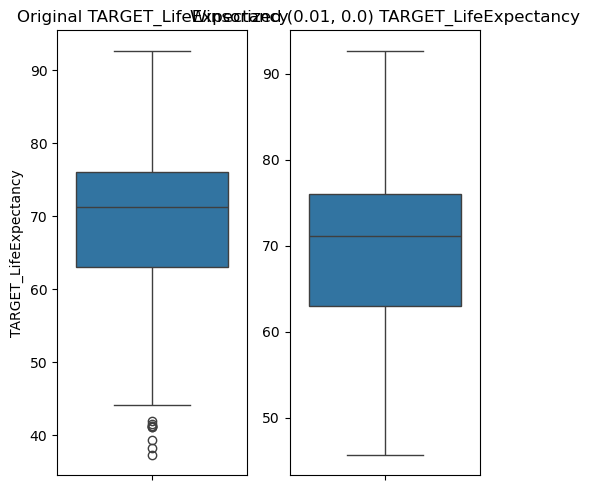

In [101]:
cols_to_winsorize = [
    {"col": "TARGET_LifeExpectancy", "lower": 0.01, "upper": 0.0},
    {"col": "AdultMortality", "lower": 0.0, "upper": 0.03},
    {"col": "AdultMortality-Male", "lower": 0.0, "upper": 0.03},
    {"col": "AdultMortality-Female", "lower": 0.0, "upper": 0.03},
    {"col": "SLS", "lower": 0.0, "upper": 0.05},
    {"col": "PercentageExpenditure", "lower": 0.0, "upper": 0.15},
    {"col": "Measles", "lower": 0.0, "upper": 0.185},
    {"col": "Under5LS", "lower": 0.0, "upper": 0.05},
    {"col": "Polio", "lower": 0.09, "upper": 0.0},
    {"col": "TotalExpenditure", "lower": 0.0, "upper": 0.02},
    {"col": "Diphtheria", "lower": 0.1, "upper": 0.0},
    {"col": "HIV-AIDS", "lower": 0.0, "upper": 0.18},
    {"col": "GDP", "lower": 0.0, "upper": 0.15},
    {"col": "Population", "lower": 0.0, "upper": 0.14},
    {"col": "Thinness10-19years", "lower": 0.0, "upper": 0.055},
    {"col": "Thinness5-9years", "lower": 0.0, "upper": 0.055},
    {"col": "IncomeCompositionOfResources", "lower": 0.055, "upper": 0.0},
    {"col": "Schooling", "lower": 0.02, "upper": 0.0},
]

cols_to_plot = ["TARGET_LifeExpectancy"]

winsorized_data_dict = {}
for col in cols_to_winsorize:
    if col["col"] in df.columns:
        show_plot = False

        if col["col"] in cols_to_plot:
            show_plot = True

        winsorize_column(
            col=col["col"],
            lower_limit=col["lower"],
            upper_limit=col["upper"],
            show_plot=show_plot,
        )
    else:
        print(f"WARNING: Column '{col['col']} not found in Dataset")

After completing the outliers detections and data cleaning process, the cleaned dataset was saved into a new variable named `clean_df` for further analysis.

In [102]:
clean_df = df.copy()

# Apply the winsorized values to the new `clean_df``
for col, data in winsorized_data_dict.items():
    if col in df.columns:
        clean_df[col] = data
        print(f"Updated column '{col}' with Winsorized values")

# Check outliers again
for col in clean_df.columns:

    # skip column `Year`, `Status`, and `Country`
    if col in ["Year", "Status", "Country"]:
        continue

    analyze_outliers_iqr(col, df=clean_df)

Updated column 'TARGET_LifeExpectancy' with Winsorized values
Updated column 'AdultMortality' with Winsorized values
Updated column 'AdultMortality-Male' with Winsorized values
Updated column 'AdultMortality-Female' with Winsorized values
Updated column 'SLS' with Winsorized values
Updated column 'PercentageExpenditure' with Winsorized values
Updated column 'Measles' with Winsorized values
Updated column 'Under5LS' with Winsorized values
Updated column 'Polio' with Winsorized values
Updated column 'TotalExpenditure' with Winsorized values
Updated column 'Diphtheria' with Winsorized values
Updated column 'HIV-AIDS' with Winsorized values
Updated column 'GDP' with Winsorized values
Updated column 'Population' with Winsorized values
Updated column 'Thinness10-19years' with Winsorized values
Updated column 'Thinness5-9years' with Winsorized values
Updated column 'IncomeCompositionOfResources' with Winsorized values
Updated column 'Schooling' with Winsorized values
+------------------------

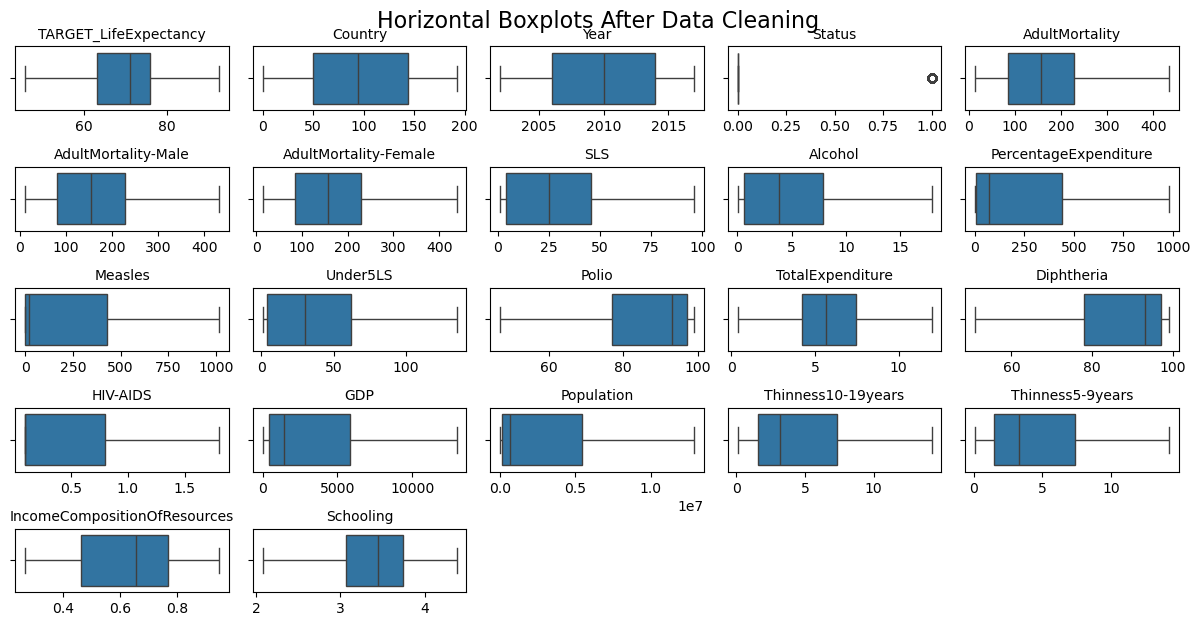

In [103]:
fig, axs = create_boxplots(
    clean_df,
    cols=clean_df.columns,
    n_rows=5,
    figsize=(12, 6),
    horizontal=True,
    title="Horizontal Boxplots After Data Cleaning",
)
plt.show()

## 3) Data Analysis

### Exploring Data Distributions with Histogram

The histogram displays the distribution of all features in the dataset, offering a clear overview of how each variable is spread across its range after the data cleaning process. 

**Before Cleaning**

- Many features, such as `Measles`, `Under5LS`, `GDP`, `PercentageExpenditure` show the highly skewed distribution, with extreme right-tail values.
- Some features, such as `PercentageExpenditure`, range from very low to excessively high values (even over 10,000), which makes it challenging for models to interpret the relationship.

**After Cleaning**

- Distributions become more compact and readable (e.g., `GDP`, `Population`, `PercentageExpenditure`)
- Skewness is reduced, allowing the visual focus to shift toward the majority value range for each variable.

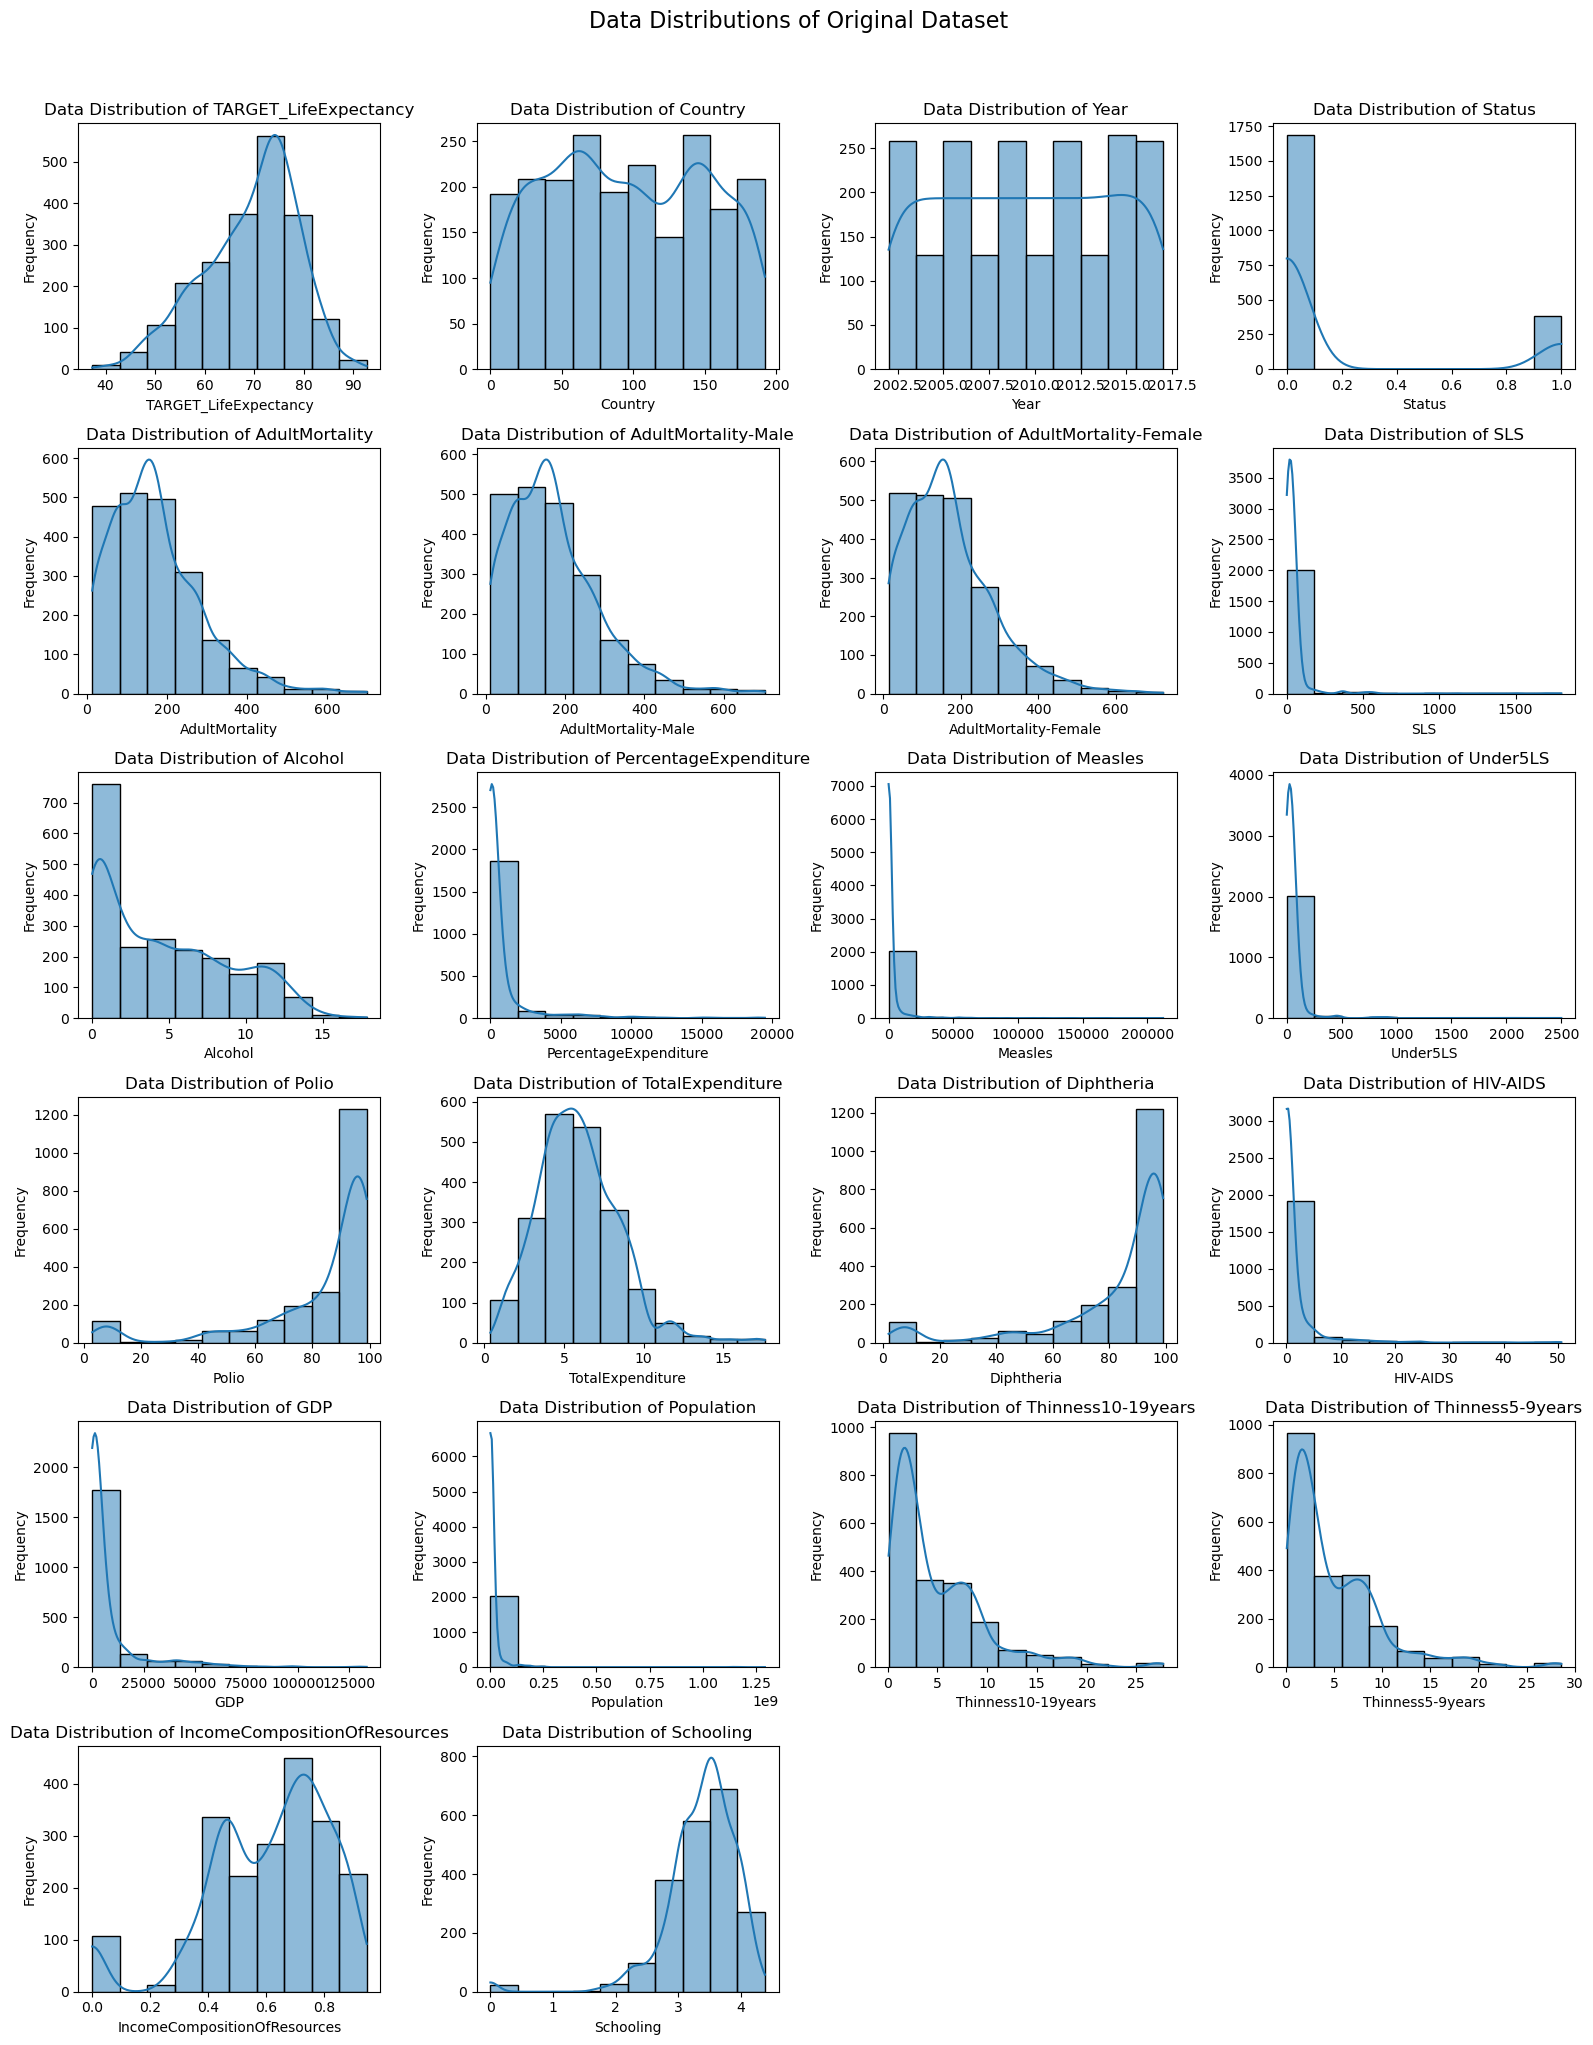

In [104]:
plot_data_distributions(
    df,
    bins=10,
    kde=True,
    n_cols=4,
    figsize=(16, 20),
    title="Data Distributions of Original Dataset",
)
plt.show()

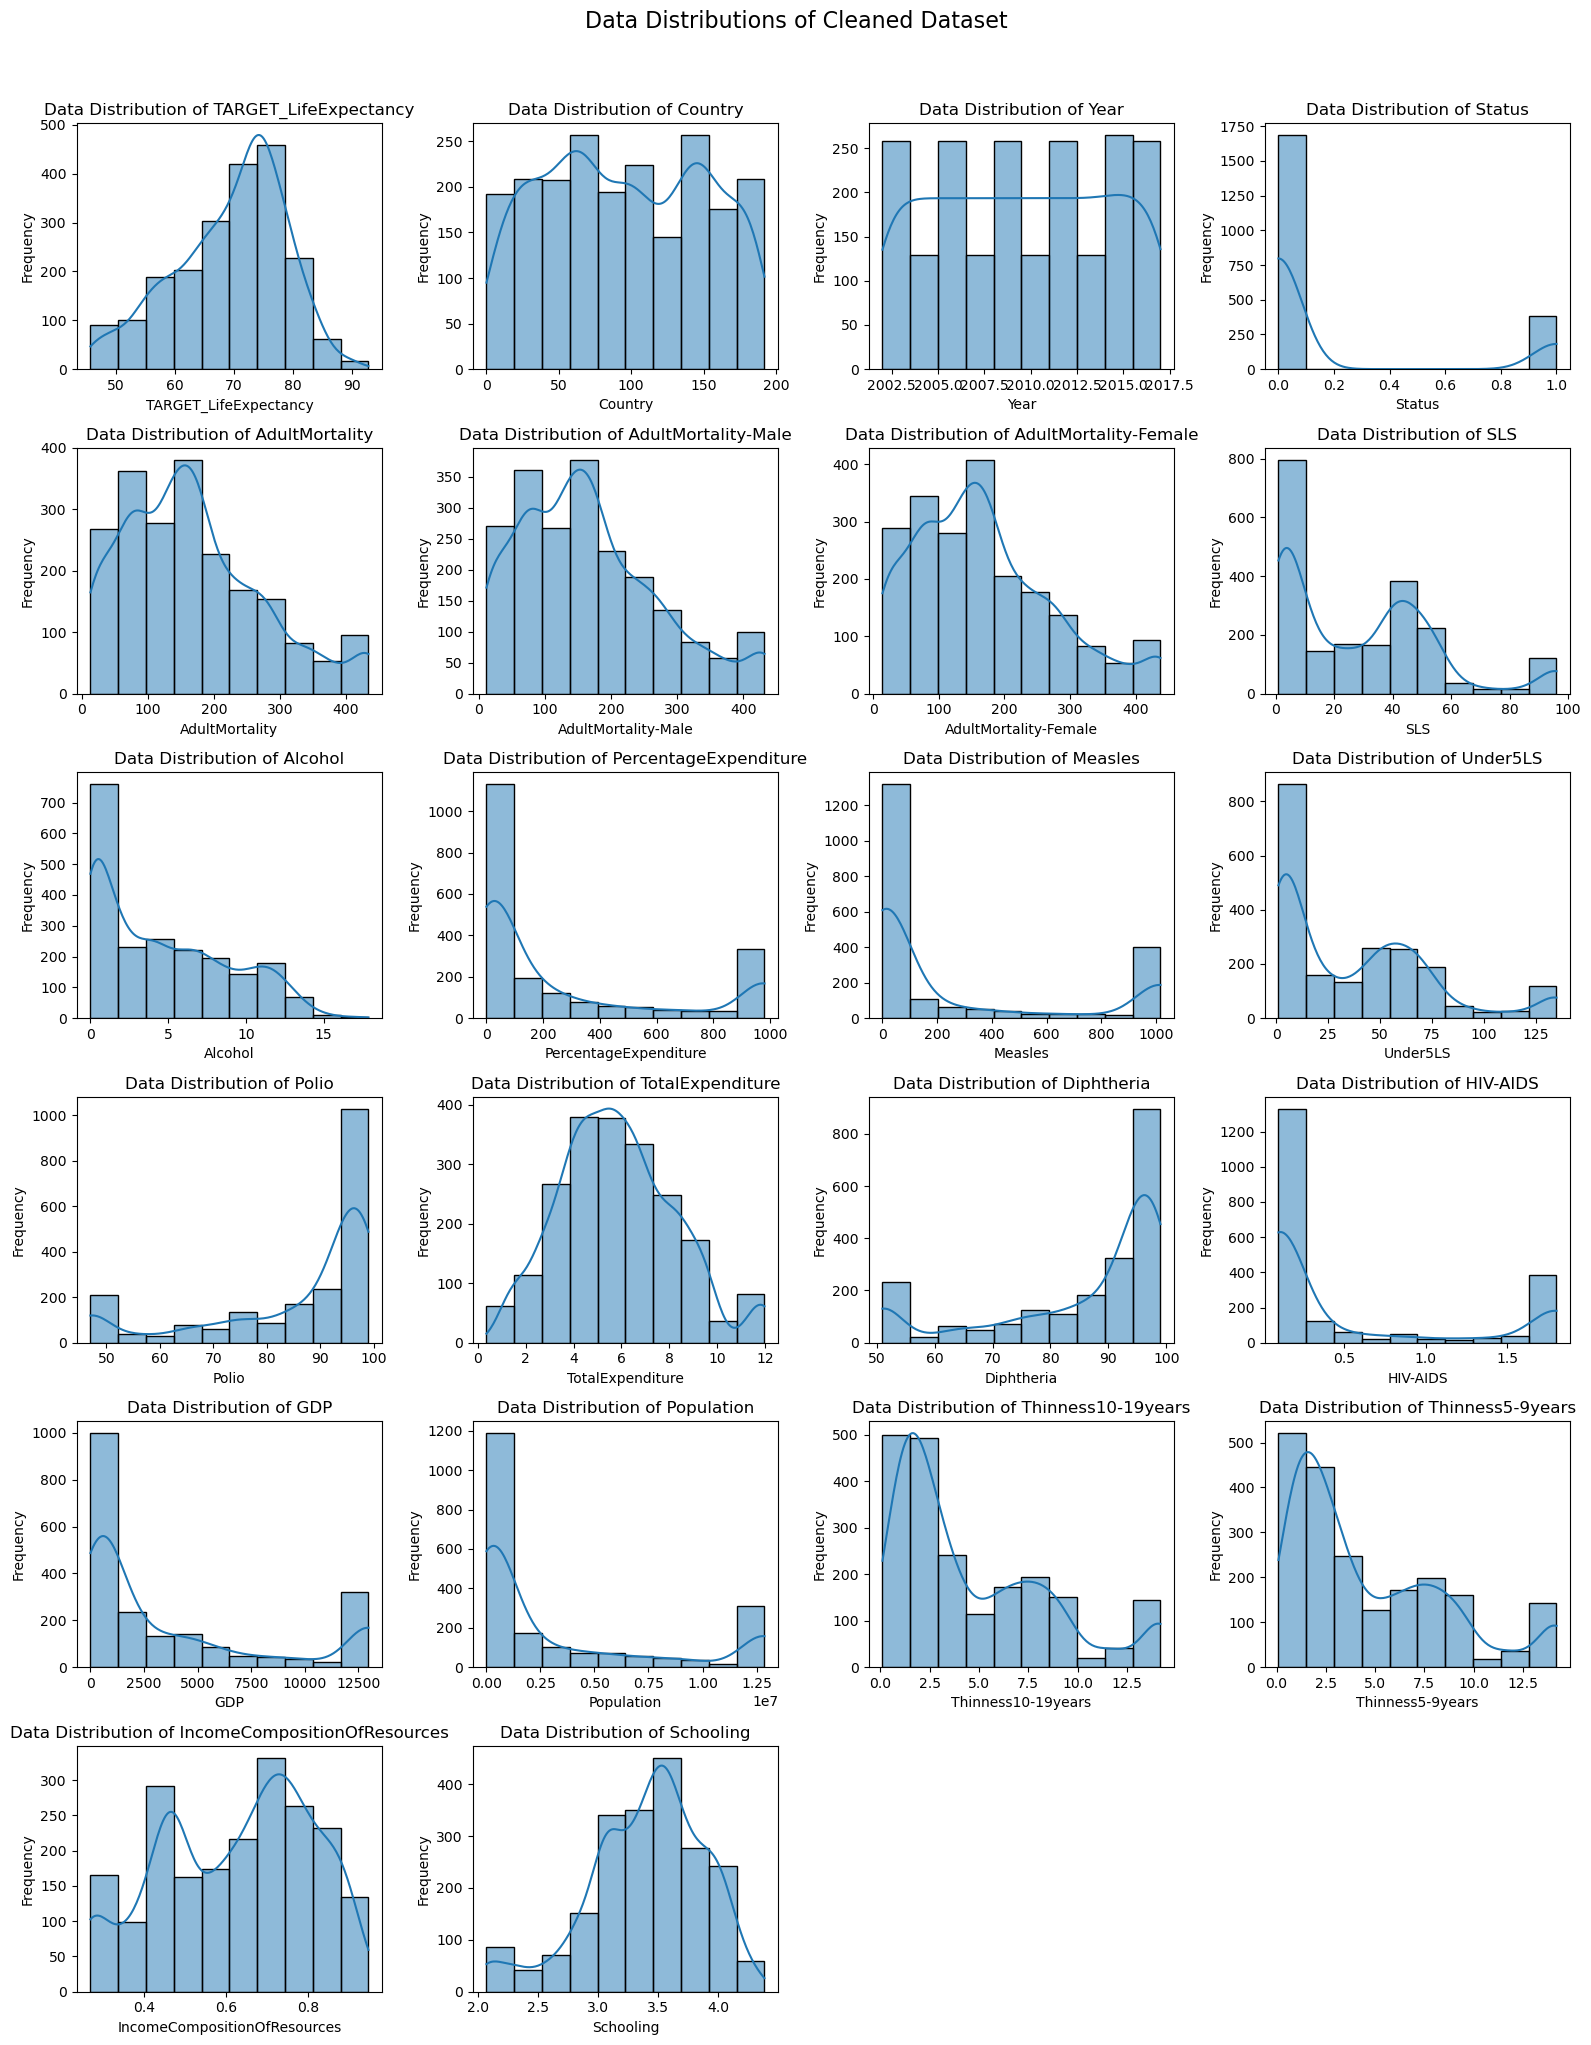

In [105]:
plot_data_distributions(
    clean_df,
    bins=10,
    kde=True,
    n_cols=4,
    figsize=(16, 20),
    title="Data Distributions of Cleaned Dataset",
)
plt.show()

### 3.1) Univariate Analysis

From the distribution plots, we can observe that most features are continuous, except the `Country`, `Year`, and `Status`. The next section focuses on analyzing the role and potential impact of these three categorical variables in the dataset.

#### Discover `Country`, `Year`, and `Status`

- We can observe that the dataset includes data from **136 countries**, and it is represented by a numerical index instead of the country names.

- Most of the data (about 81%) comes from **developing countries**.

- Moreover, the dataset was captured from **2002 to 2017**, covering a 16-year time period.

In [106]:
print_header('`country` value counts')
clean_df['Country'].value_counts()

+--------------------------------------------+
|           `COUNTRY` VALUE COUNTS           |
+--------------------------------------------+


Country
146.0    16
150.0    16
34.0     16
178.0    16
132.0    16
         ..
152.0     1
173.0     1
119.0     1
85.0      1
92.0      1
Name: count, Length: 136, dtype: int64

In [107]:
print_header('`year` value counts')
clean_df['Year'].value_counts().sort_index()

+-----------------------------------------+
|           `YEAR` VALUE COUNTS           |
+-----------------------------------------+


Year
2002.0    129
2003.0    129
2004.0    129
2005.0    129
2006.0    129
2007.0    129
2008.0    129
2009.0    129
2010.0    129
2011.0    129
2012.0    129
2013.0    129
2014.0    129
2015.0    136
2016.0    129
2017.0    129
Name: count, dtype: int64

In [108]:
print_header('`status` value counts')
status_count = clean_df['Status'].value_counts()
status_count

+-------------------------------------------+
|           `STATUS` VALUE COUNTS           |
+-------------------------------------------+


Status
0.0    1687
1.0     384
Name: count, dtype: int64

The pie chart below clearly reveals that the majority of the dataset originates from developing countries. This imbalance suggests that any model trained on this data may be biased toward patterns observed in developing nations. As a result, appropriate techniques will be needed to address these issues

+------------------------------------------------------------------------+
|           DISTRIBUTION OF DEVELOPING AND DEVELOPED COUNTRIES           |
+------------------------------------------------------------------------+


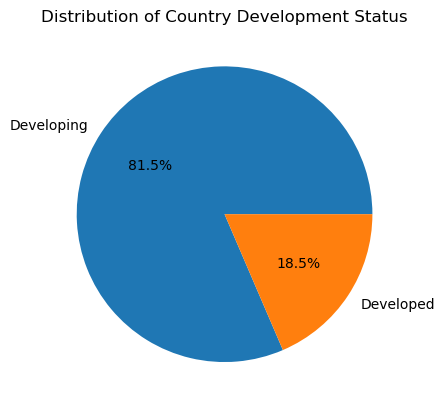

In [109]:
print_header("Distribution of Developing and Developed Countries")

labels = ["Developing", "Developed"]

# Plot the pie chart
plt.pie(
    status_count,
    labels=labels,
    autopct="%1.1f%%",
)
plt.title("Distribution of Country Development Status")
plt.show()

### 3.2) Bivariate Analysis

**Target Life Expectancy** appears to be very strongly correlated with:
- `AdultMortality` and its variant (correlation ≈ **–0.65**)
- `HIV-AIDS` (-0.75), indicating that higher prevalence is associated with lower life expectancy
- `IncomeCompositionOfResources` (+0.74), suggesting better access to income and resources leads to longer life expectancy
- `Schooling` (+0.71) shows the positive influence of education on life expectancy

In contrast, the **target variable** shows a very weak correlation with both `Country` (0.08) and `Population` (-0.07), indicating minimal linear relationships.

**Correlation Among Independent Variables**

- `AdultMortality`, `AdultMortality-Male`, and `AdultMortality-Female` show perfect correlation (> 0.98) — only one should be retained.

- `Under5LS` and `SLS` (0.96), as well as `Thinness5-9years` and `Thinness10-19years` (0.93), capture nearly identical age-related health information.

- A strong economic-related correlation is seen between `GDP` and `PercentageExpenditure` (0.85).

- Immunization variables `Diphtheria` and `Polio` also strongly correlate (0.85), likely due to similar public health infrastructure.

- Lastly, `Schooling` and `IncomeCompositionOfResources` correlate at 0.86, reflecting the link between education and resource accessibility.

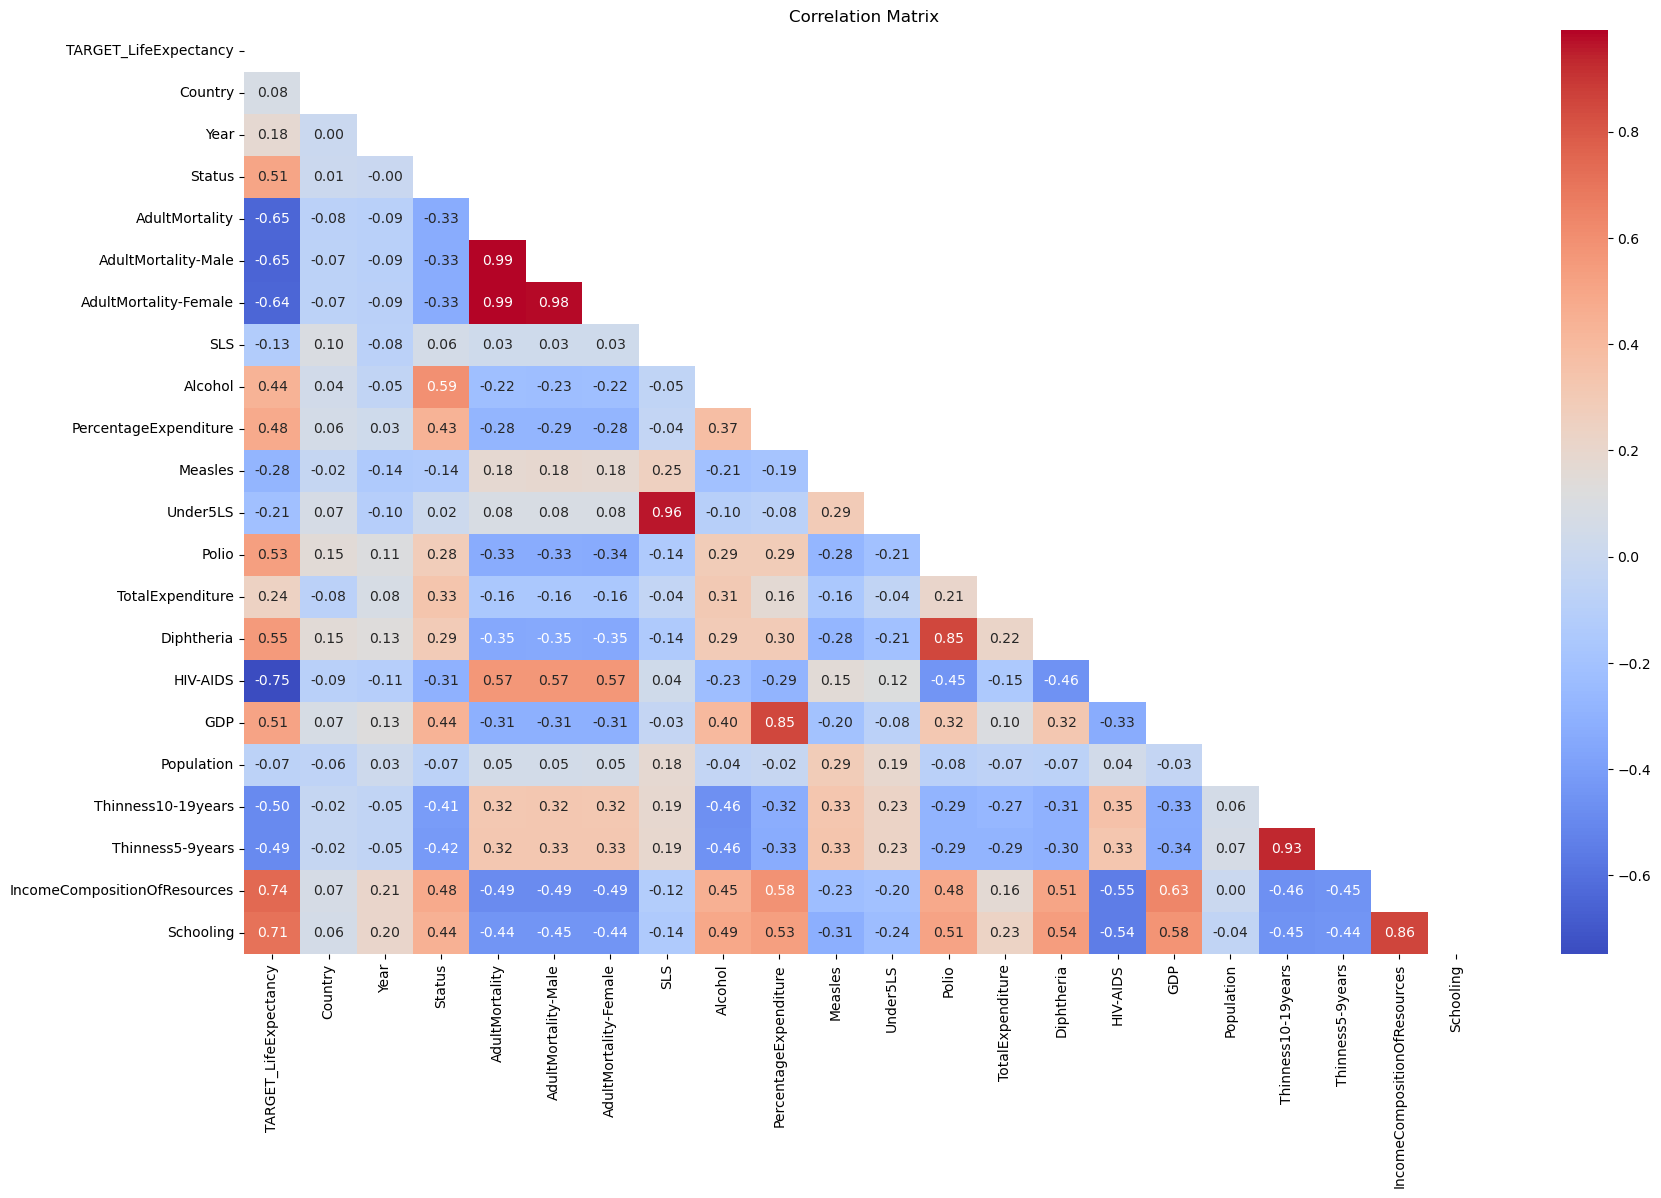

In [110]:
plot_correlation_matrix(clean_df)

To better understand how key features influence life expectancy, I plotted the some variables. These plots help to visually validate the strength and direction of the relationships between:


#### `LifeExpectancy` vs `Status`

The figure reveals a clear distinction in life expectancy between developed and developing countries. On average, developed nations generally have significantly higher life expectancy, highlighting the impact of socio-economic factors, healthcare systems, and living conditions on life expectancy. 

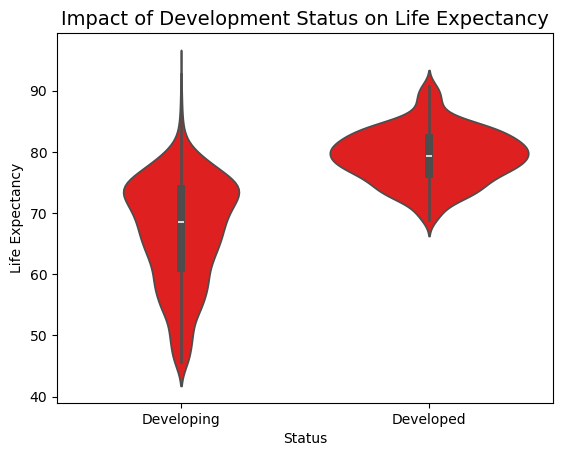

In [111]:
sns.violinplot(
    data=clean_df, x=clean_df["Status"], y=clean_df["TARGET_LifeExpectancy"], hue=None, color="r"
)
plt.xticks(ticks=[0, 1], labels=["Developing", "Developed"])
plt.title("Impact of Development Status on Life Expectancy", fontsize=14)
plt.ylabel("Life Expectancy")
plt.show()

#### `LifeExpectancy` vs `Year`

It’s useful to explore how life expectancy has changed over the years.

The graph shows a **upward trend** in life expectancy over the 16 captured years (2002 to 2017). This suggests that, on average, people have been living longer over time, likely due to improvement in healthcare, socio-economic factors, and living conditions

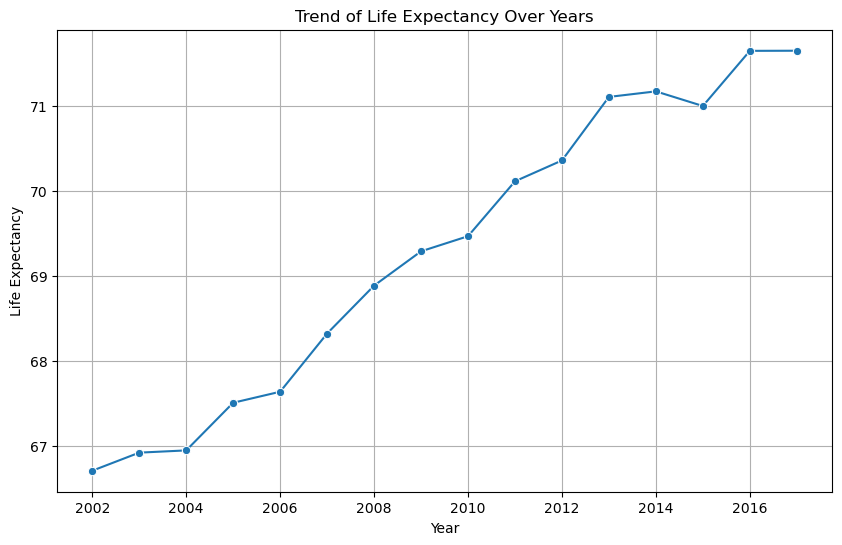

In [ ]:
# Group by year and calculate mean life expectancy
trend_data = clean_df.groupby("Year")["TARGET_LifeExpectancy"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data, x="Year", y="TARGET_LifeExpectancy", marker="o")
plt.title("Trend of Life Expectancy Over Years")
plt.ylabel("Life Expectancy")
plt.xlabel("Year")
plt.grid(True)
plt.show()

#### `Adult Mortality` vs `Target Life Expectancy`

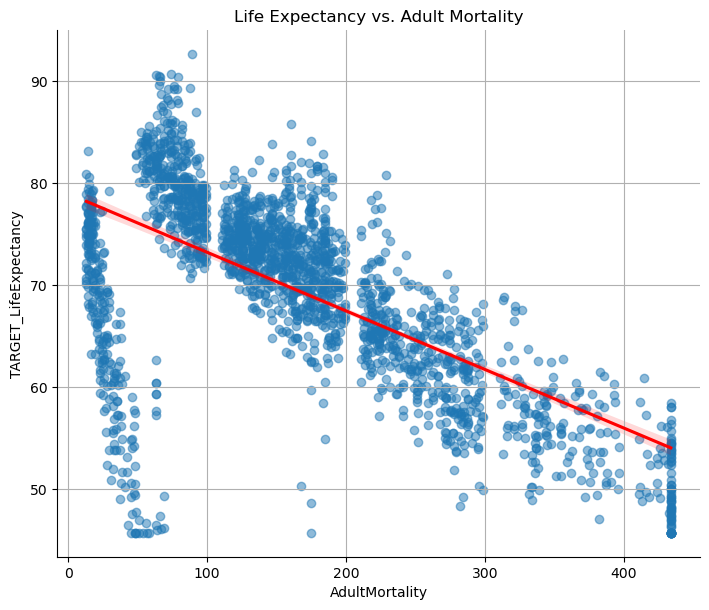

In [113]:
create_regression_plot(
    df=clean_df,
    x="AdultMortality",
    y="TARGET_LifeExpectancy",
    title="Life Expectancy vs. Adult Mortality",
)
plt.show()

#### `HIV-AIDS` vs `Target Life Expectancy`

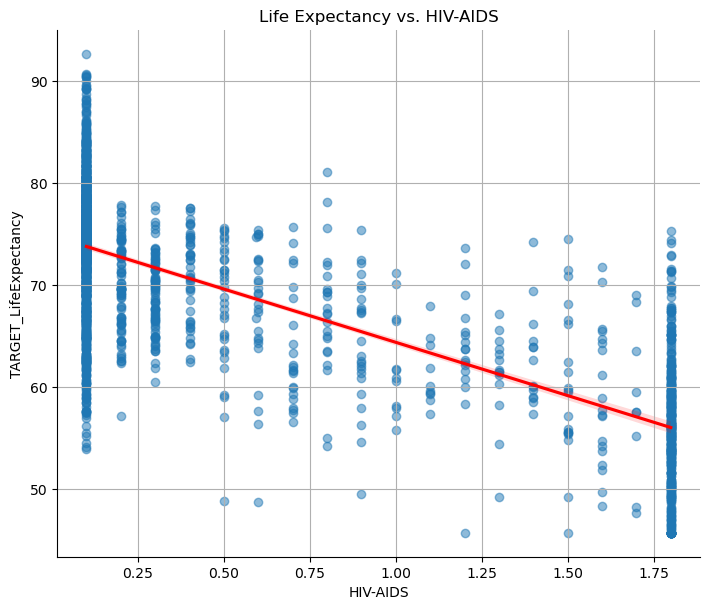

In [114]:
create_regression_plot(
    df=clean_df,
    x="HIV-AIDS",
    y="TARGET_LifeExpectancy",
    title="Life Expectancy vs. HIV-AIDS",
)
plt.show()

#### `Income Composition of Resources` vs `Life Expectancy`

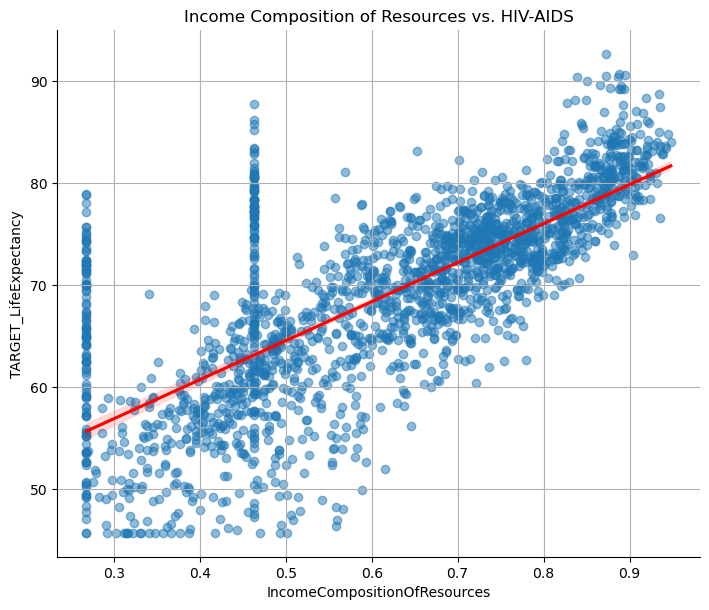

In [115]:
create_regression_plot(
    df=clean_df,
    x="IncomeCompositionOfResources",
    y="TARGET_LifeExpectancy",
    title="Income Composition of Resources vs. HIV-AIDS",
)
plt.show()

#### `Schooling` vs `Life Expectancy`

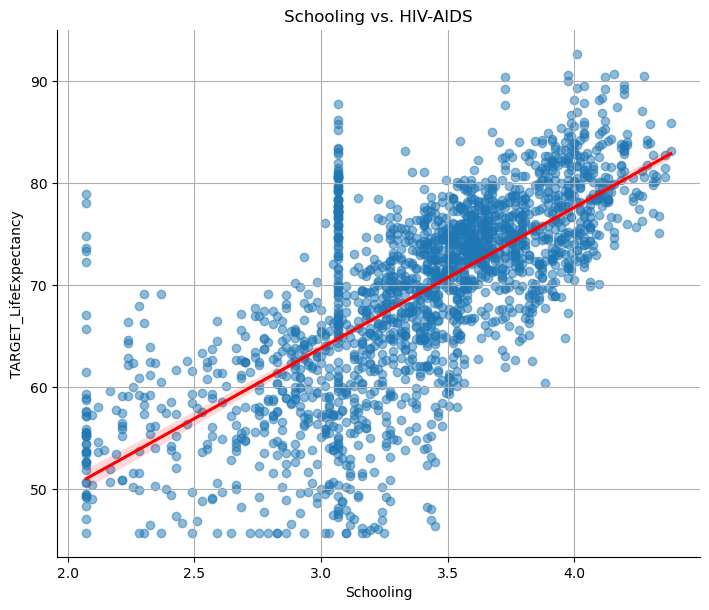

In [116]:
create_regression_plot(
    df=clean_df,
    x="Schooling",
    y="TARGET_LifeExpectancy",
    title="Schooling vs. HIV-AIDS",
)
plt.show()

#### Compare All Features with Target


			+---------------------------------------------------+
			|           CLEAN DATASET REGRESSION PLOT           |
			+---------------------------------------------------+


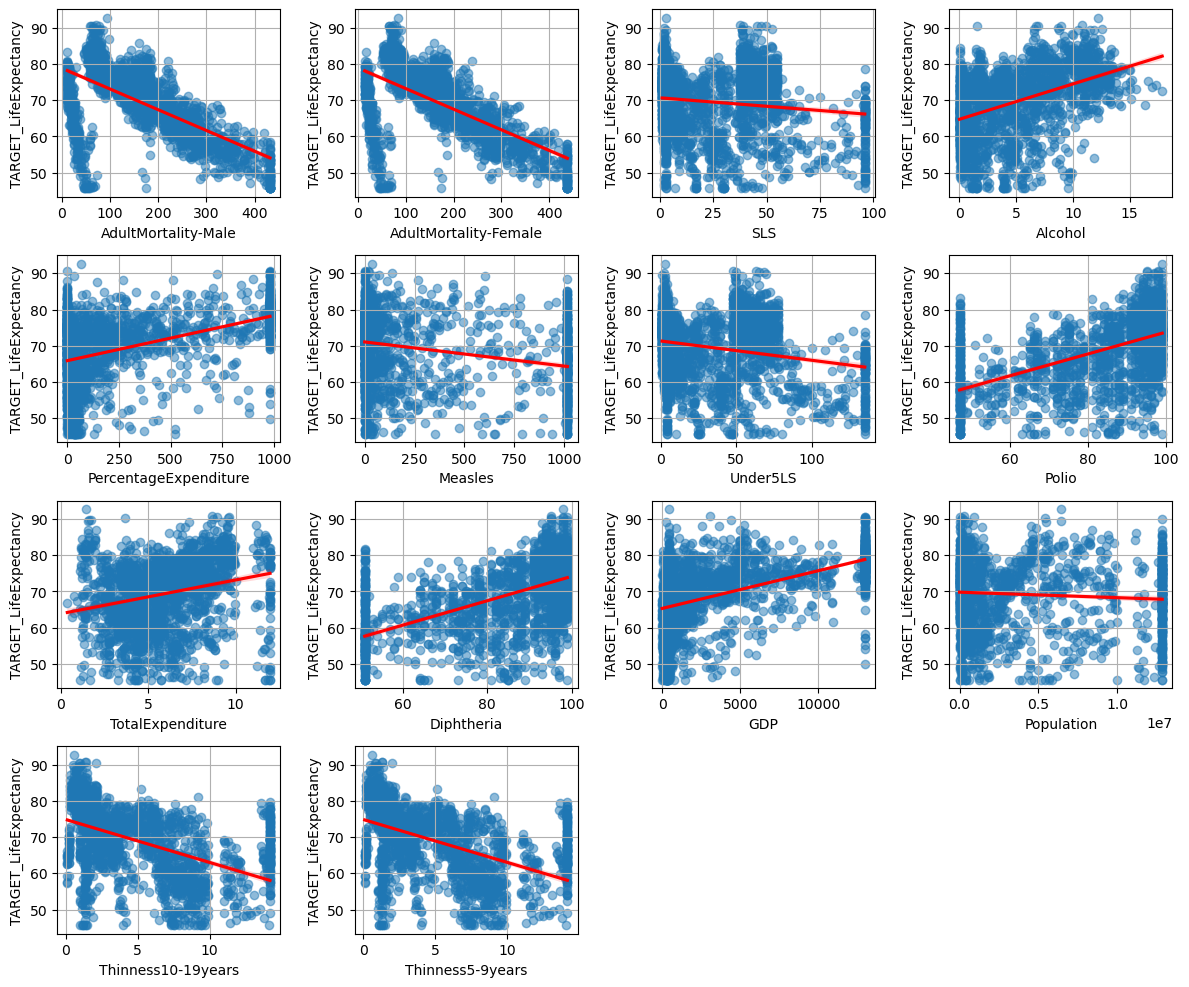

In [117]:
print_header("clean dataset regression plot", tabs=True)
plot_features = clean_df.drop(
    [
        "TARGET_LifeExpectancy",
        "Status",
        "Country",
        "Year",
        "AdultMortality",
        "HIV-AIDS",
        "IncomeCompositionOfResources",
        "Schooling",
    ],
    axis=1,
    errors="ignore",
)

plots = create_regression_plot(
    df=clean_df,
    x=plot_features.columns.tolist(),
    y="TARGET_LifeExpectancy",
    multi=True,
    height=12,
    figsize=(12, 12),
    cols=4,
    rows=5,
)

			+-------------------------------------------------+
			|           OLD DATASET REGRESSION PLOT           |
			+-------------------------------------------------+


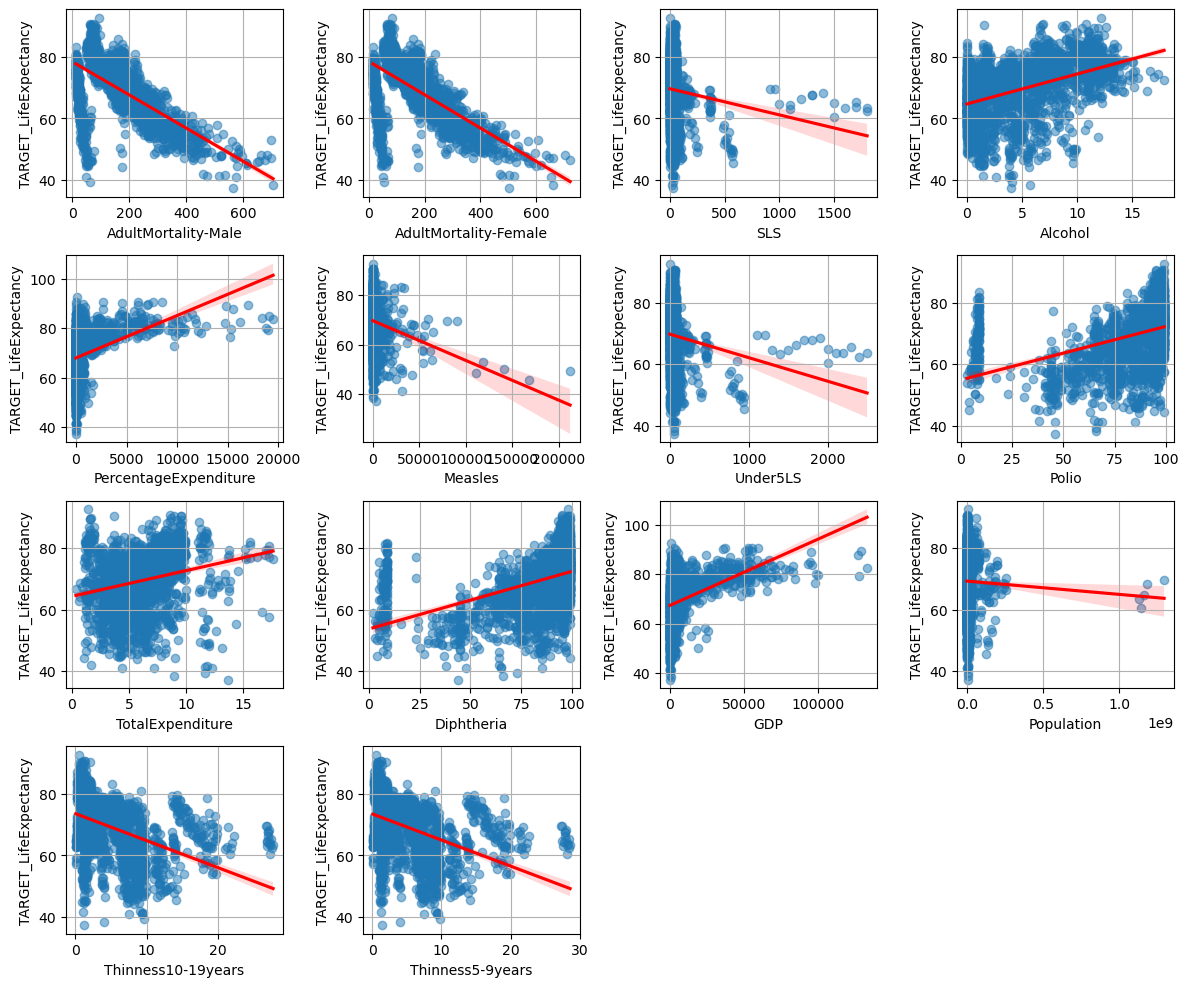

In [118]:
print_header("old dataset regression plot", tabs=True)
plots = create_regression_plot(
    df=df,
    x=plot_features.columns.tolist(),
    y="TARGET_LifeExpectancy",
    multi=True,
    height=12,
    figsize=(12, 12),
    cols=4,
    rows=5,
)

### 3.3) Comparing Regression Plots: Original vs. Cleaned Dataset

The two regression plots above also visualize the relationships between features and the target variable (`TARGET_LifeExpectancy`) before and after [data cleaning](#1-data-cleaning):

1. **Original Dataset**:
- Many plots (e.g., `Measles`, `GPD`, `Under5LS`) show **extremely stretched axes** due to the presence of **outliers**.
- Regression lines are **less representative** of the central data trend due to the influence of these extreme values.
- Visual clutter makes it challenging to spot the underlying correlation.

2. **Cleaned Dataset**:
- The plots appear **less noisy** with fewer extreme values.
- The regression lines are more **stable and smoother**, suggesting more reliable trends.
- Some features such as `Measles`, `GPD`, and `Under5LS` now show **stronger and more consistent relations** with life expectancy.

# V. DATA PREPROCESSING

## 1) Feature Selection

#### Feature Selection Based on High Correlation

In the dataset, several features exhibit extremely high correlations with each other. This may harm model performance since it adds redundancy and instability to the learned coefficients

To address multicollinearity, I will drop features with very high correlations with the target and retain only one representative from each group.

- `AdultMortality`: I will keep this feature as it represents the general mortality rate, consisting of both `AdultMortality-Male` and `AdultMortality-Female`.

- `Under5LS` vs `SLS`: I will keep `Under5LS` as it has a stronger correlation with the target variable and remove `SLS`.

- `GDP` vs `PercentageExpenditure`: I will keep `GDP` since it has a better correlation with the target. 

- `Thinness10-19years` vs `Thinness5-9years`: I will retain `Thinness10-19years` as it shows a better correlation with the target.

- `Polio`, and `Schooling` are dropped since they have the weaker correlations compared to `Diptheria` and `IncomeCompositionOfResources` 

- `Country`: This feature is the categorical index with a very low correlation to the target. It is dropped because it doesn't contribute to the model training.

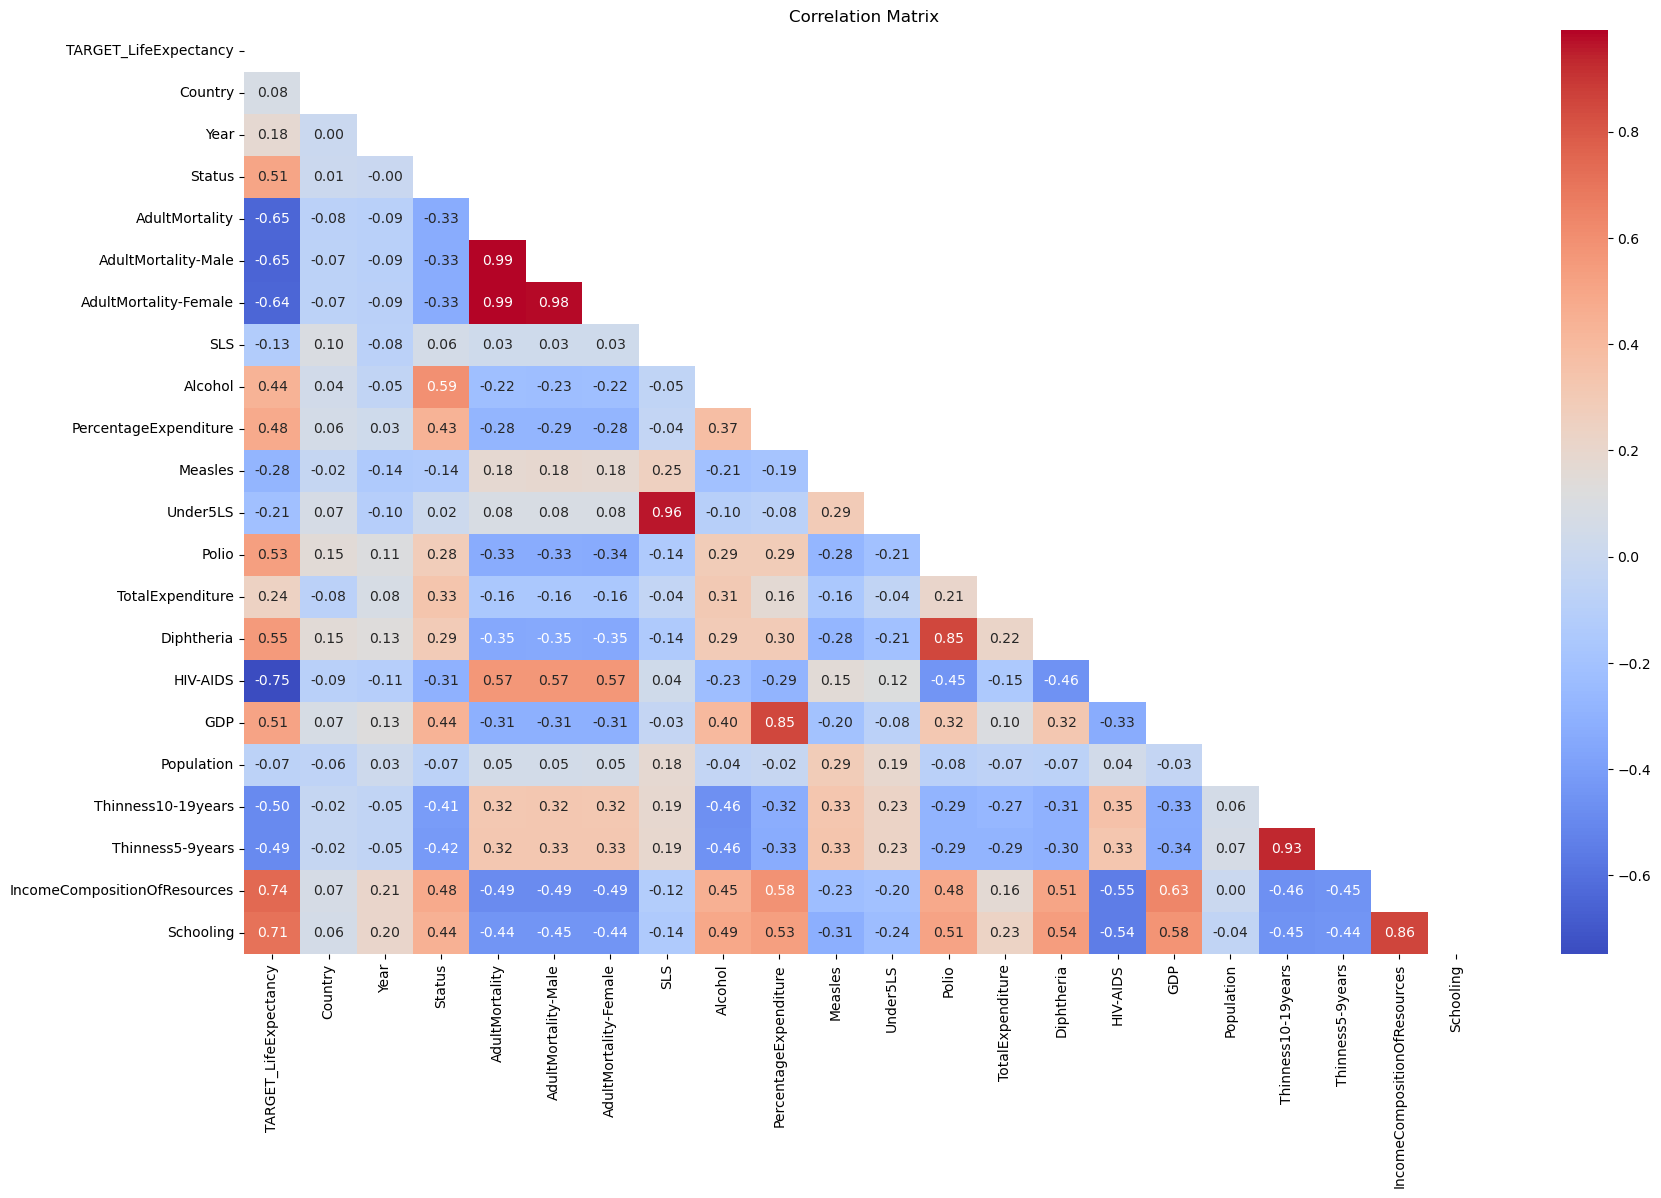

In [119]:
plot_correlation_matrix(clean_df)

In [120]:
columns_to_drop = [
    "AdultMortality-Male",
    "AdultMortality-Female",
    "SLS",
    "Polio",
    "PercentageExpenditure",
    "Thinness5-9years",
    "Schooling",
    "Country",
]

selected_df = clean_df.drop(columns_to_drop, axis=1, errors="ignore")


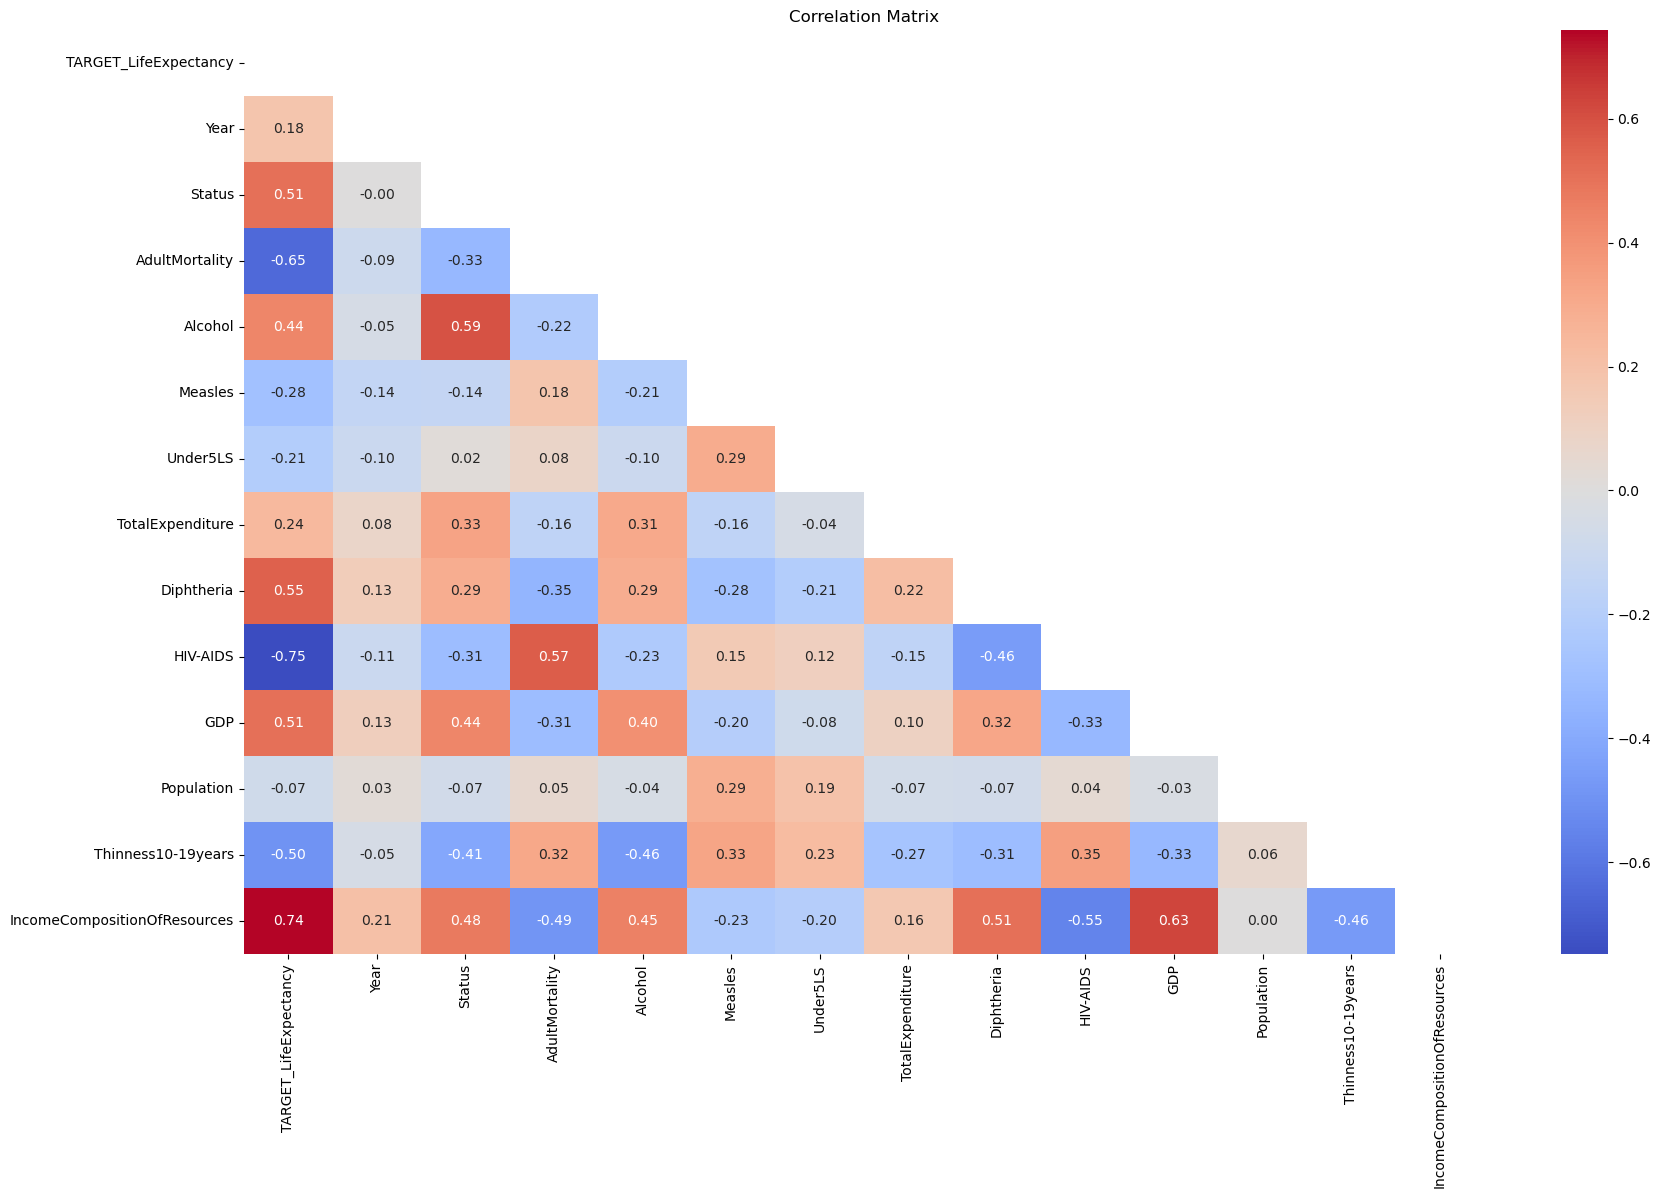

In [121]:
plot_correlation_matrix(selected_df)

### Correlation between all features and `Life Expectancy`

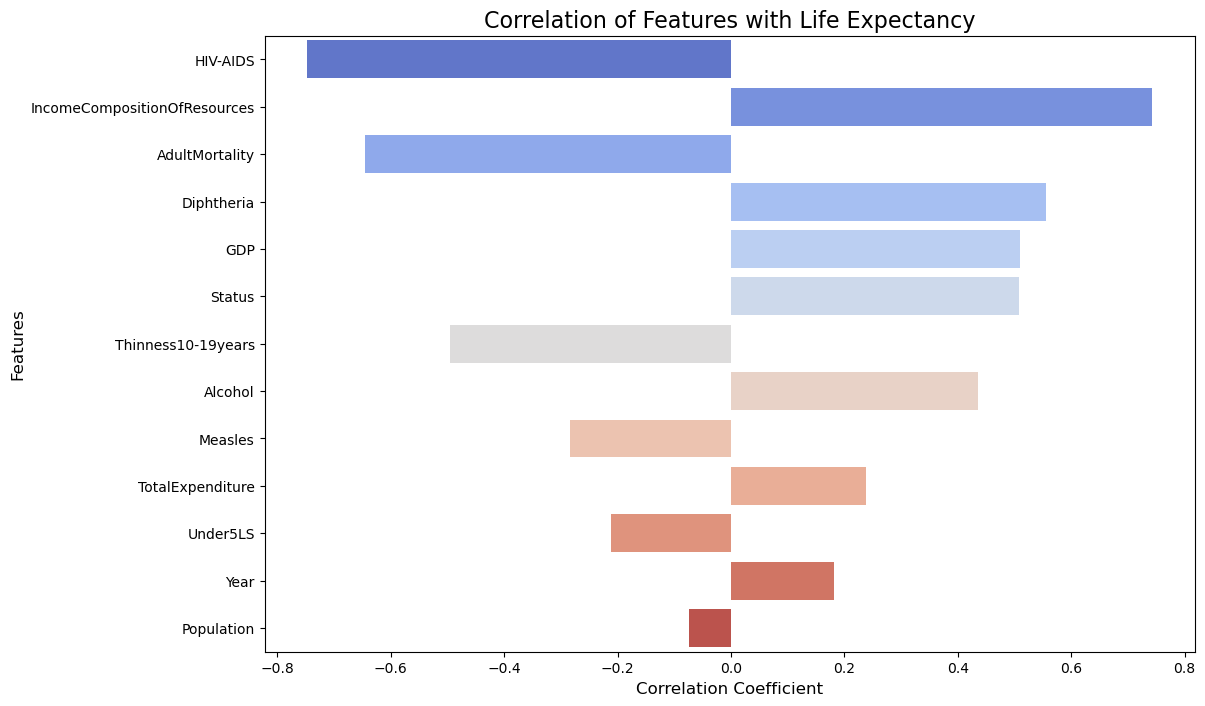

In [122]:
# Calculate the correlation of all features with the target variable
target_correlations = selected_df.corr()["TARGET_LifeExpectancy"].drop(
    "TARGET_LifeExpectancy"
)

# Sort the correlations by absolute value (keep the sign)
correlations_sorted = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=correlations_sorted.values,
    y=correlations_sorted.index,
    palette="coolwarm",
    hue=correlations_sorted.index,
    dodge=False,
    legend=False,
)

plt.title("Correlation of Features with Life Expectancy", fontsize=16)
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

## 2) Split The Dataset

Before applying any preprocessing, I split the dataset to prevent data leakage. This guarantees that the test set remains truly unseen and the transformations are fitted only on the training data.


In [123]:
x = selected_df.drop(
    ["TARGET_LifeExpectancy"],
    axis=1,
)
y = selected_df["TARGET_LifeExpectancy"]

print_header("Shapes of `x` and target `y`")
print("X Shape:", x.shape)
print("Y Shape:", y.shape)

+--------------------------------------------------+
|           SHAPES OF `X` AND TARGET `Y`           |
+--------------------------------------------------+
X Shape: (2071, 13)
Y Shape: (2071,)


In [124]:
random_state = 19

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    shuffle=True,
    test_size=0.2,
    random_state=random_state,
)

print_header("shape of train and test dataset")
print("Train X Shape:", x_train.shape)
print("Train Y Shape:", y_train.shape)
print("Test X Shape:", x_test.shape)
print("Test Y Shape:", y_test.shape)

+-----------------------------------------------------+
|           SHAPE OF TRAIN AND TEST DATASET           |
+-----------------------------------------------------+
Train X Shape: (1656, 13)
Train Y Shape: (1656,)
Test X Shape: (415, 13)
Test Y Shape: (415,)


## 3) Feature Scaling

Feature scaling is a vital step in machine learning as it prevents issues related to scale differences (domain problems) and is important for models depending on distance-based calculations.

**Standardization (Z-scores Normalization)**

This method rescales features so that the dataset has **a mean of 0** and a **standard deviation of 1**.

- **Formula**:
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

- **Benefits**:
  - Handle outliers better than Min-Max scaling.
  - Does not bound data to a specific range, preserving the variance.

- **Drawbacks**
  - Transformed data may not be easily interpretable due to a lack of a fixed range.
  - Modify the original distribution of the data.

**Min max Scaler (Normalization)**

Scales features to a **fixed range** [0, 1].

- **Formula**:
$$x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

- **Benefits**:
  - Preserves the shape of the original distribution
  - Keep all features within the same range

- **Drawbacks**
  - Sensitive to outliers
  - Not ideal if data is not uniformly distributed

Given the life expectancy dataset, I selected **Standardization** as it ensures each feature contributes equally to the model training process. Additionally, it’s more robust to outliers and doesn’t distort the underlying data distribution.

In [125]:
# I don't scale these features (as they are categories type)
exclude_cols = ["Year", "Status"]

x_train_scaled_part = x_train.drop(columns=exclude_cols)
x_test_scaled_part = x_test.drop(columns=exclude_cols)

scaler = StandardScaler()

# fit the scaler with `x_train_scaled_part`
scaler.fit(x_train_scaled_part)

x_train_scaled = scaler.transform(x_train_scaled_part)
x_test_scaled = scaler.transform(x_test_scaled_part)

# Convert back to DataFrames with the `exclude_cols``
x_train_scaled = pd.DataFrame(
    x_train_scaled, columns=x_train_scaled_part.columns, index=x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled, columns=x_test_scaled_part.columns, index=x_test.index
)

x_train_scaled = pd.concat([x_train_scaled, x_train[exclude_cols]], axis=1)
x_test_scaled = pd.concat([x_test_scaled, x_test[exclude_cols]], axis=1)

file_path = "./saved_scalers/standard_scaler.joblib"
joblib.dump(scaler, file_path)

print(f"Scaler is saved to {file_path} successfully.Data successfully transformed.")

Scaler is saved to ./saved_scalers/standard_scaler.joblib successfully.Data successfully transformed.


In [126]:
x_train_scaled.describe()

,AdultMortality,Alcohol,Measles,Under5LS,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,IncomeCompositionOfResources,Year,Status
count,1.656000e+03,1.656000e+03,1.656000e+03,1.656000e+03,1.656000e+03,1.656000e+03,1656.000000,1.656000e+03,1.656000e+03,1.656000e+03,1.656000e+03,1656.000000,1656.000000
mean,3.346759e-16,-1.094133e-16,1.287215e-17,-9.439577e-17,-4.167359e-16,1.480297e-16,0.000000,-1.453480e-16,-5.470664e-17,3.003502e-17,2.198992e-16,2009.527174,0.181763
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,1.000302,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,4.609774,0.385766
min,-1.472626e+00,-1.109706e+00,-6.776644e-01,-9.925290e-01,-2.259164e+00,-2.179363e+00,-0.637319,-8.307530e-01,-7.239457e-01,-1.161037e+00,-1.963544e+00,2002.000000,0.000000
25%,-7.914701e-01,-9.638923e-01,-6.776644e-01,-9.127748e-01,-6.897640e-01,-4.625811e-01,-0.637319,-7.403259e-01,-6.964600e-01,-7.819250e-01,-8.878321e-01,2006.000000,0.000000
50%,-1.112681e-01,-2.097230e-01,-6.282218e-01,-2.614492e-01,-9.061379e-02,4.911864e-01,-0.637319,-5.207880e-01,-5.787553e-01,-3.775388e-01,1.740884e-01,2009.000000,0.000000
75%,5.542861e-01,7.249211e-01,4.533363e-01,6.345390e-01,6.692082e-01,7.455244e-01,0.403968,3.905338e-01,4.374408e-01,6.587007e-01,7.850375e-01,2014.000000,0.000000
max,2.510245e+00,3.159538e+00,1.834022e+00,2.569824e+00,2.546476e+00,8.726934e-01,1.891521,2.016400e+00,2.051703e+00,2.402616e+00,1.771107e+00,2017.000000,1.000000


In [127]:
x_test_scaled.describe()

,AdultMortality,Alcohol,Measles,Under5LS,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,IncomeCompositionOfResources,Year,Status
count,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000,415.000000
mean,-0.014191,0.047925,-0.107948,-0.006735,0.035515,0.089685,0.016129,0.042884,0.000772,0.001390,-0.001347,2009.484337,0.200000
std,0.997773,1.020342,0.932566,0.957904,0.986122,0.926849,1.005112,1.043864,1.005647,0.979745,1.032419,4.636978,0.400483
min,-1.472626,-1.109706,-0.677664,-0.992529,-2.097456,-2.179363,-0.637319,-0.829772,-0.723945,-1.161037,-1.963544,2002.000000,0.000000
25%,-0.782010,-0.967478,-0.677664,-0.912775,-0.635861,-0.271828,-0.637319,-0.740326,-0.696460,-0.769288,-0.887832,2005.000000,0.000000
50%,-0.138696,-0.158329,-0.643055,-0.168403,0.008899,0.554771,-0.637319,-0.521002,-0.595389,-0.377539,0.171330,2010.000000,0.000000
75%,0.599223,0.911372,-0.053451,0.629139,0.641220,0.745524,0.552723,0.548050,0.449445,0.683975,0.836065,2013.000000,0.000000
max,2.510245,2.518912,1.834022,2.569824,2.546476,0.872693,1.891521,2.016400,2.051703,2.402616,1.787656,2017.000000,1.000000


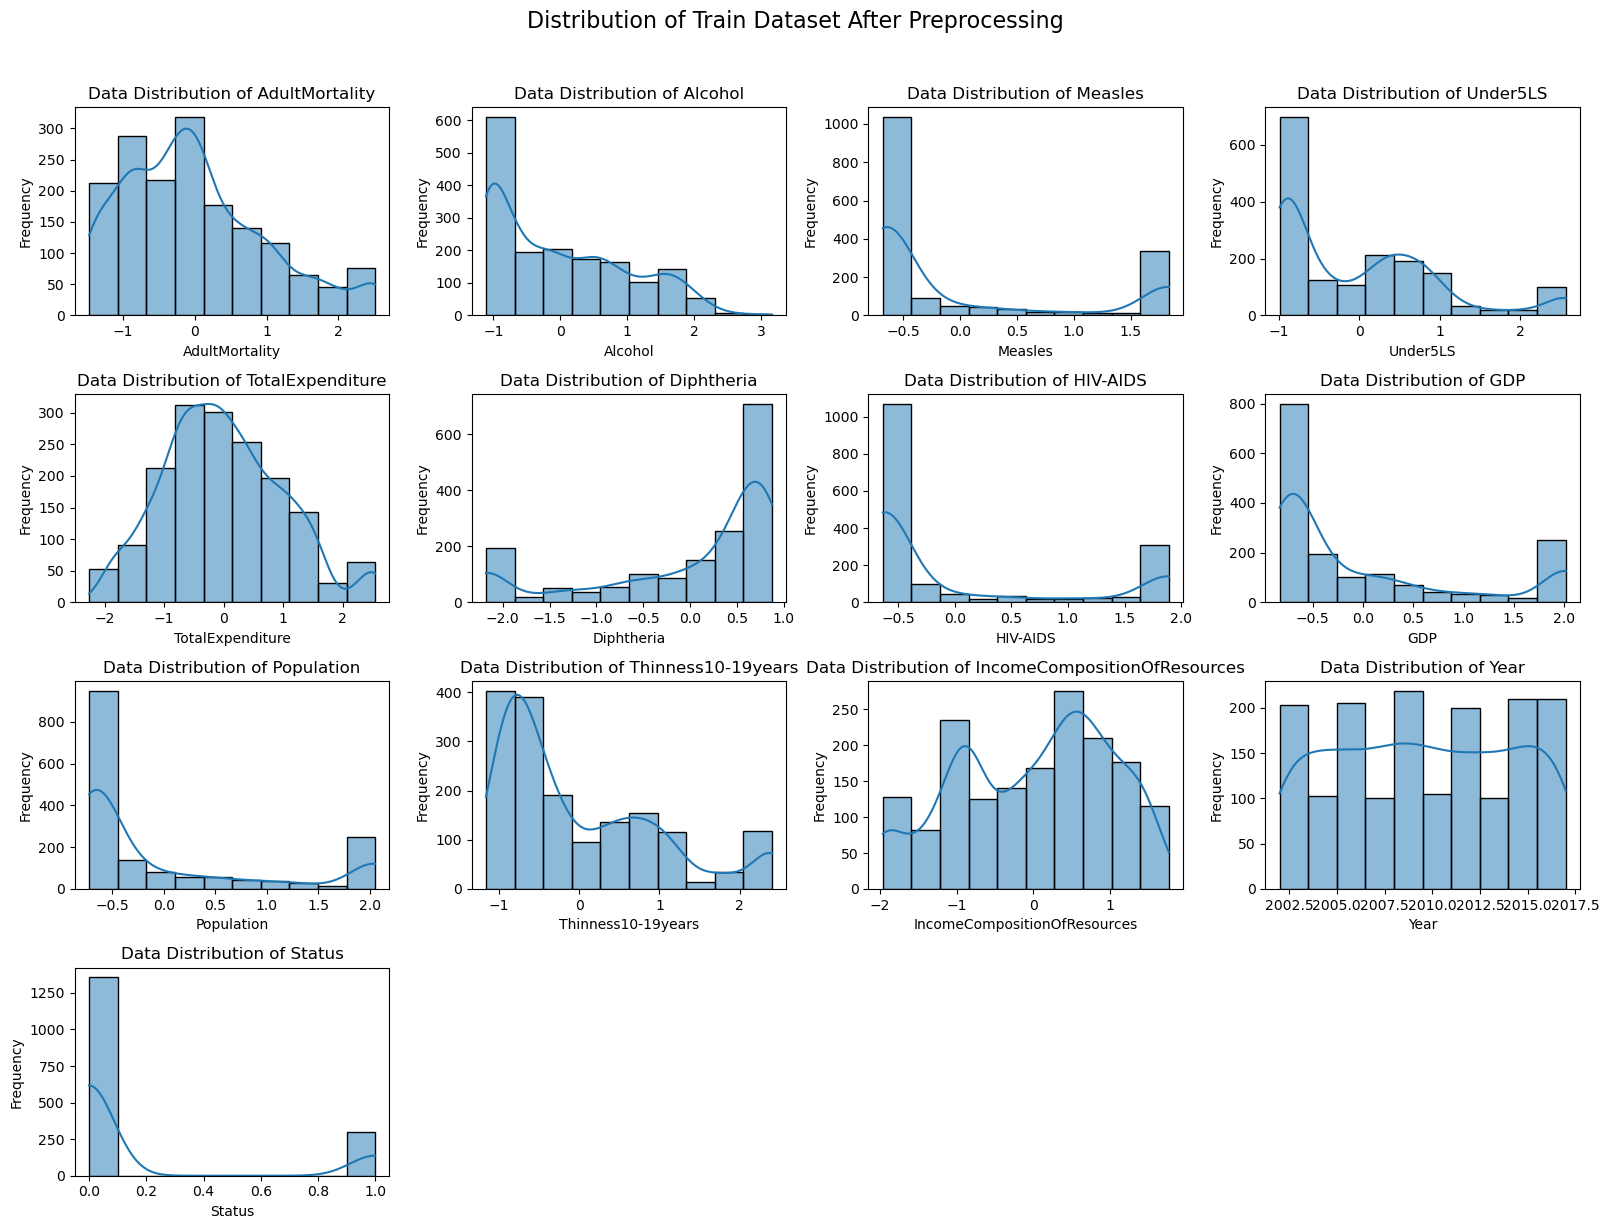

In [128]:
plot_data_distributions(x_train_scaled, title="Distribution of Train Dataset After Preprocessing")

# VI. MODEL TRAINING

In this section, I used a total of **9 different models**. This approach helps analyze the strengths of each algorithm and identify the best one for this dataset.
 
The model training includes:
- [Linear Regression](#41-linear-regression)
- [Polynomial Linear Regression](#42-polynomial-linear-regression)
- [Lasso Regression](#43-lasso-regression)
- [Ridge Regression](#44-ridge-regression)
- [Decision Tree](#45-decision-tree)
- [Random Forest](#46-random-forest)
- [XGBoost](#47-xgboost)
- [Neural Network](#48-k-nearest-neighbors-regression)
- [Support Vector Regression (SVR)](#49-svr-support-vector-regressor)

To ensure the optimal performance for each model, I used `GridSearchCV` for hyperparameter tuning. Using this technique, I can identify the optimal combination of parameters based on cross-validation results. This maximizes the performance of all models and guarantees a fair comparison across different algorithms

## 1) Helper Functions for Model Training

To make the training, evaluate and visualization process easier, I implemented several functions before going through the training process.

### 1.1) Visualize Model Prediction

the `visualize_model_prediction` function plots the predicted and actual values to visualize the regression model's performance. The x-axis represents the ground truth, while the y-axis represents the predicted value. The red line represents an ideal model, where predictions align perfectly with the actual values. If all the points closely align with the red line, it indicates that the model is well-fitting.

In [129]:
def visualize_model_predictions(y_true, y_pred, model_name):
    """
    Plots predicted vs actual values for a regression model.

    Parameters:
    y_true : array
        Ground truth target values.
    y_pred : array
        Predicted target values by the model.
    model_name : str
        Name of the model for display.
    """

    residuals = y_pred - y_true
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left subplot represent predicted vs Actual
    sns.scatterplot(
        x=y_true, y=y_pred, color="skyblue", edgecolor="k", s=60, alpha=0.7, ax=axes[0]
    )

    axes[0].plot(
        [min(y_true), max(y_true)],
        [min(y_true), max(y_true)],
        color="red",
        label="Ideal",
        linewidth=2,
    )
    axes[0].set_title(f"{model_name} - Predictions vs Actual", fontsize=14)
    axes[0].set_xlabel("Actual Values")
    axes[0].set_ylabel("Predicted Values")
    axes[0].legend()
    axes[0].grid(True)

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        color="orange",
        edgecolor="k",
        s=60,
        alpha=0.7,
        ax=axes[1],
    )
    axes[1].axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Residual")
    axes[1].set_title(f"{model_name} - Residual Plot", fontsize=14)
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### 1.2) Save Model

In the training process, I applied the `GridSearchCV`, which will find the optimal hyperparameters for each model to perform the best score. However, this process is computationally intensive and time-consuming. Therefore, the `save_model` function is implemented to save the model in the first training process, which helps avoid re-training and reduces CPU usage.

This function will store the trained model along with its best parameters, cross-validation results, and predicted values in a local `.joblib` file. In future runs, the model can be loaded directly without re-training. 

In [130]:
def save_model(
    model,
    model_name,
    params=None,
    cv_results=None,
    metrics=None,
    y_pred=None,
    y_train_pred=None,
):
    """
    Save a trained model and its associated information to disk.

    Parameters:
    model : trained model object
        The trained machine learning model to save
    model_name : str
        Name to use for the saved file
    params : dict, optional
        Model hyperparameters
    cv_results : dict, optional
        Cross-validation results
    metrics : dict, optional
        The metric scores
    y_pred: array
        stores the predictions of model
    """

    # Create directory for saved models if it doesn't exist
    os.makedirs("saved_models", exist_ok=True)
    filename = os.path.join("saved_models", f"{model_name.replace(' ', '')}.joblib")

    model_info = {
        "model": model,
        "params": params,
        "cv_results": cv_results,
        "metrics": metrics,
        "y_pred": y_pred,
        "y_train_pred": y_train_pred,
    }

    # Save the model information to disk
    try:
        joblib.dump(model_info, filename)
        print(f"Model successfully saved to {filename}")
        return filename
    except Exception as e:
        print(f"Error saving model: {e}")
        return None

### 1.3) Load and Show Model Info

Along with the `save_model` function, the load function is used to load the model from the local file to show all the necessary information.

In [131]:
def load_and_show_model_info(filepath, model_name, show_params=False):
    """
    load the model from file `.joblib` and print out the scores

    Parameters:
        filepath: string
            the file path to model
        model_name: string
            name of the model
        show_params: bool
            if True, print out the best parameters of model

    Returns:
        dict of model information
    """
    print(f"[INFO] Loading saved model from: {filepath}")
    try:
        model_info = joblib.load(filepath)

        model = model_info.get("model", None)
        metrics = model_info.get("metrics", {})
        y_pred = model_info.get("y_pred", None)
        y_train_pred = model_info.get("y_train_pred", None)
        cv_results = model_info.get("cv_results", None)

        if show_params:
            print_header(f"{model_name.upper()} - GridSearchCV Best Parameters")
            params = model_info.get("params", {})
            print(params)

        print_header(f"{model_name.upper()} - EVALUATION RESULTS")

        print(f"{'Train R² Score':<35}: {metrics.get('r2_train','N/A'):.4f}")
        print(f"{'R² Score':<35}: {metrics.get('r2_score', 'N/A'):.4f}")
        print(f"{'Mean Absolute Error (MAE)':<35}: {metrics.get('mae', 'N/A'):.4f}")
        print(f"{'Mean Squared Error (MSE)':<35}: {metrics.get('mse', 'N/A'):.4f}")
        print(
            f"{'Root Mean Squared Error (RMSE)':<35}: {metrics.get('rmse', 'N/A'):.4f}"
        )

        return {
            "model": model,
            "model_name": model_name,
            "cv_results": cv_results,
            **metrics,
            "y_pred": y_pred,
            "y_train_pred": y_train_pred,
            "model_file": filepath,
        }
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

### 1.4) Train and Evaluate Model with Grid Search

The `train_and_evaluate_model` function trains a given model, evaluates it using regression metrics (R², MAE, MSE, RMSE), and saves the model into a file by using the `save_model` function.

Moreover, `train_and_evaluate_model_gridsearch` performs hyperparameter tuning using `GridSearchCV`, then finds the best model and evaluates it by utilizing the `train_and_evaluate_model`.

In [132]:
def train_and_evaluate_model(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    model_name="",
    show_thetas=False,
    filepath="",
    save=False,
    grid=None,
):
    """
    Train a model and evaluate its performance on the test set

    Parameters:
    model :  
        The machine learning model to train.
    x_train : pandas DataFrame or numpy array
        Training features.
    y_train : pandas Series or numpy array
        Training target values.
    x_test : pandas DataFrame or numpy array
        Test features.
    y_test : pandas Series or numpy array
        Test target values.
    model_name : str
        Name of the model (for display purposes).
    show_thetas : bool, optional (default=False)
        If True, displays the model's coefficients
    filepath : str, optional (default="")
        The file path to save the trained model. If provided and `save` is True, the model
        will be saved to this location.
    save : bool, optional (default=False)
        If True, saves the trained model and its associated information
    grid : GridSearchCV object, optional (default=None)
        This is a GridSearchCV object used for hyperparameter tuning.

    Returns:
    dict
        A dictionary containing evaluation metrics (R², MAE, MSE, RMSE) and predictions from the best model.
    """
    print(f"[INFO] No saved model found for '{filepath}'. Training now...")

    # Train the model
    model.fit(x_train, y_train)

    # Check if show_thetas is True and the model has a 'coef_' attribute
    if show_thetas and hasattr(model, "coef_"):
        print_header("Model Coefficients (Thetas)")
        print("Intercept (Theta0):", model.intercept_)
        print("Coefficients (Theta1):", model.coef_)

    # Predict the target
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Calculate evaluation metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2 = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)

    print_header(f"{model_name.upper()} - EVALUATION RESULTS")
    print(f"{'Train R² Score':<35}: {r2_train:.4f}")
    print(f"{'R² Score':<35}: {r2:.4f}")
    print(f"{'Mean Absolute Error (MAE)':<35}: {mae:.4f}")
    print(f"{'Mean Squared Error (MSE)':<35}: {mse:.4f}")
    print(f"{'Root Mean Squared Error (RMSE)':<35}: {rmse:.4f}")

    metrics = {
        "r2_train": r2_train,
        "r2_score": r2,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
    }

    results = {
        "model_name": model_name,
        **metrics,  # unpack to append `metrics`` to `results``
        "y_pred": y_test_pred,
        "y_train_pred": y_train_pred,
    }

    # Save the model
    if save:
        # Extract parameters and cv_results if using GridSearch
        params = (
            grid.best_params_ if grid else getattr(model, "get_params", lambda: None)()
        )
        cv_results = grid.cv_results_ if grid else None

        filename = save_model(
            model=model,
            model_name=model_name,
            params=params,
            cv_results=cv_results,
            metrics=metrics,
            y_pred=y_test_pred,
            y_train_pred=y_train_pred,
        )

        results["model_file"] = filename

    return results

In [133]:
def train_and_evaluate_model_gridsearch(
    model,
    param_grid,
    x_train,
    y_train,
    x_test,
    y_test,
    model_name="",
    cv=5,
    filepath="",
    save=False,
):
    """
    Perform GridSearchCV for hyperparameter tuning and evaluate the best model.

    Parameters
     model : sklearn model
        The machine learning model to train.
    param_grid : dict
        A dictionary with parameter names (str) as keys and lists of parameter settings to try as values.
    x_train : pandas DataFrame or numpy array
        Training features.
    y_train : pandas Series or numpy array
        Training target values.
    x_test : pandas DataFrame or numpy array
        Test features.
    y_test : pandas Series or numpy array
        Test target values.
    model_name : str, optional (default="")
        A name for the model to display in printed output.
    cv : int or cross-validation generator, optional (default=5)
        Determines the cross-validation splitting strategy.
    filepath : str, optional (default="")
        The file path to save the trained model. If provided and `save` is True, the model
        will be saved to this location.
    save : bool, optional (default=False)
        If True, saves the trained model and its associated information

    Returns
    dict
        A dictionary containing evaluation metrics (R², MAE, MSE, RMSE) and predictions from the best model.
    """

    grid = GridSearchCV(
        estimator=model,  # Base model
        param_grid=param_grid,  # A dict defining the hyperparameters to search
        scoring="r2",  # Metric used to evaluate model's performance
        refit=True,  # Refit the best model
        cv=cv,  # Number of folds in cross-validation (or using KFold object)
        return_train_score=True,  # Store training scores
        n_jobs=-1,  # Use all CPU cores for parallel computation
    )

    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_  # get the best model in the grid search

    print_header(f"{model_name.upper()} - GridSearchCV Best Parameters")
    print(grid.best_params_)

    # Put back to the evaluate method to get scores
    return train_and_evaluate_model(
        model=best_model,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        model_name=model_name,
        grid=grid,
        filepath=filepath,
        save=save,
    )

In [134]:
def plot_alpha_vs_score(cv_results, model, model_name=""):
    """
    Plot the mean cross-validated R² score vs alpha value

    Parameters:
    cv_results: dict
      from GridSearch.cv_results_
    model: sklearn model
        train_model
    model_name : str, optional
        Name of model
    """

    plot_df = pd.DataFrame(
        {
            "alpha": cv_results["param_alpha"].data.astype(float),
            "mean_test_score": cv_results["mean_test_score"],
            "std_test_score": cv_results["std_test_score"],
        }
    )

    plt.figure(figsize=(10, 6))

    # Plot with Seaborn lineplot
    sns.lineplot(
        data=plot_df,
        x="alpha",
        y="mean_test_score",
        marker="o",
        label="Mean CV R² Score",
    )

    # Fill the confidence interval manually
    plt.fill_between(
        plot_df["alpha"],
        plot_df["mean_test_score"] - plot_df["std_test_score"],
        plot_df["mean_test_score"] + plot_df["std_test_score"],
        alpha=0.2,
    )

    best_alpha = model.alpha
    plt.axvline(
        best_alpha, color="red", linestyle="--", label=f"Best alpha: {best_alpha:.4f}"
    )

    plt.xscale("log")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("R² Score")
    plt.title(f"{model_name} - Cross-Validated R² Score vs Alpha")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 2) Setup cross-validation (KFold)

To ensure the reliable model evaluation, I used **K-Fold Cross Validation** with 5 splits. This method randomly divides the data into 5 subsets, then validates the model 5 times, each time using a different fold as the validation set, and the remaining parts will be for training.

In [135]:
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

## 3) Setup Result Dictionary

This dictionary is used to stores all the results from models

In [136]:
all_model_results = {}

## 4) Model Selection

### 4.1) Linear Regression



In [137]:
filepath = "./saved_models/LinearRegression.joblib"

if os.path.exists(filepath):
    all_model_results["LinearRegression"] = load_and_show_model_info(
        filepath, "Linear Regression"
    )

else:
    linear_reg = LinearRegression()

    all_model_results["LinearRegression"] = train_and_evaluate_model(
        model=linear_reg,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="Linear Regression",
        show_thetas=False,
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/LinearRegression.joblib
+------------------------------------------------------------+
|           LINEAR REGRESSION - EVALUATION RESULTS           |
+------------------------------------------------------------+
Train R² Score                     : 0.7884
R² Score                           : 0.7835
Mean Absolute Error (MAE)          : 3.3727
Mean Squared Error (MSE)           : 18.7031
Root Mean Squared Error (RMSE)     : 4.3247


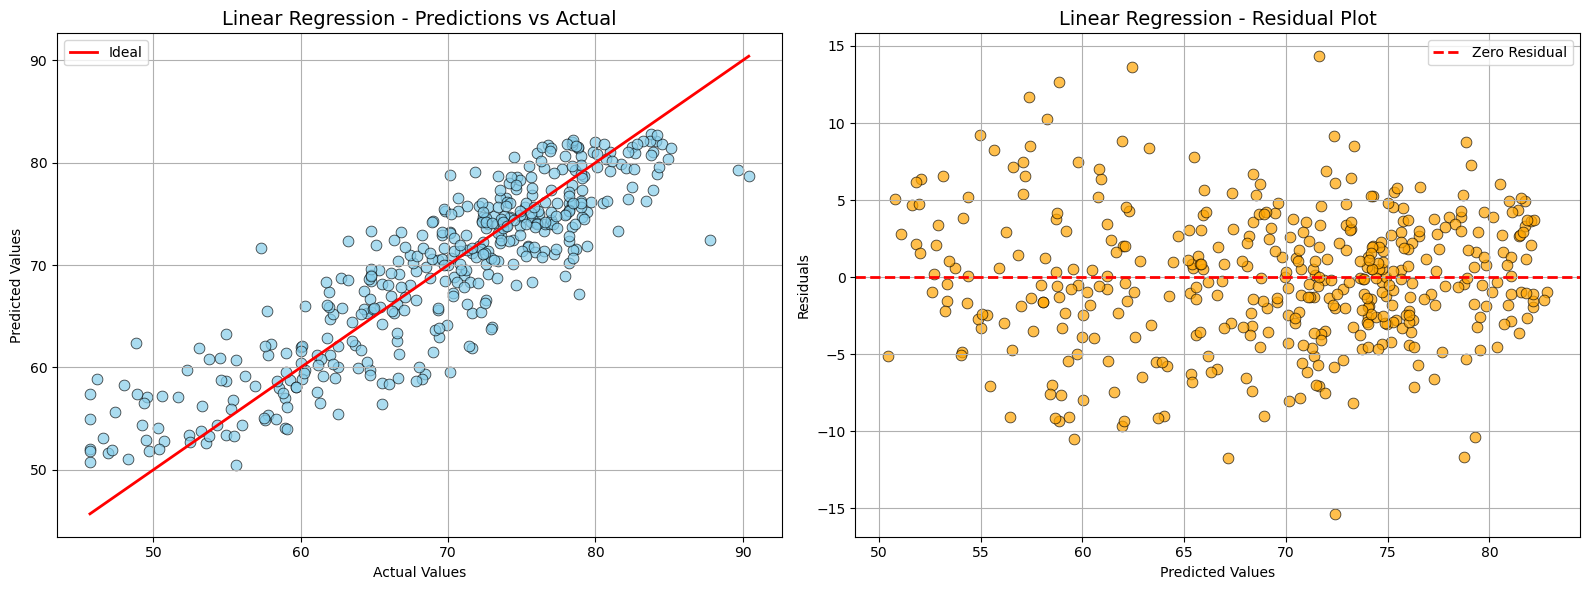

In [138]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["LinearRegression"]["y_pred"],
    model_name="Linear Regression",
);

### 4.2) Polynomial Linear Regression

#### 4.2.1) Polynomial Regression (Degree = 2)

In [139]:
filepath = "./saved_models/PolynomialRegression(Degree=2).joblib"

if os.path.exists(filepath):
    all_model_results["Polynomial2Regression"] = load_and_show_model_info(
        filepath, "Polynomial Regression (Degree = 2)"
    )
else:
    poly = PolynomialFeatures(degree=2)
    x_train_poly2 = poly.fit_transform(x_train_scaled)
    x_test_poly2 = poly.transform(x_test_scaled)

    # Scale data again after transforming to polynomial features
    scaler = StandardScaler()
    x_train_poly2 = scaler.fit_transform(x_train_poly2)
    x_test_poly2 = scaler.transform(x_test_poly2)

    # Polynomial Regression (Degree = 2)
    poly2_model = LinearRegression()

    all_model_results["Polynomial2Regression"] = train_and_evaluate_model(
        model=poly2_model,
        x_train=x_train_poly2,
        y_train=y_train,
        x_test=x_test_poly2,
        y_test=y_test,
        model_name="Polynomial Regression (Degree = 2)",
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/PolynomialRegression(Degree=2).joblib
+-----------------------------------------------------------------------------+
|           POLYNOMIAL REGRESSION (DEGREE = 2) - EVALUATION RESULTS           |
+-----------------------------------------------------------------------------+
Train R² Score                     : 0.8784
R² Score                           : 0.8676
Mean Absolute Error (MAE)          : 2.5910
Mean Squared Error (MSE)           : 11.4385
Root Mean Squared Error (RMSE)     : 3.3821


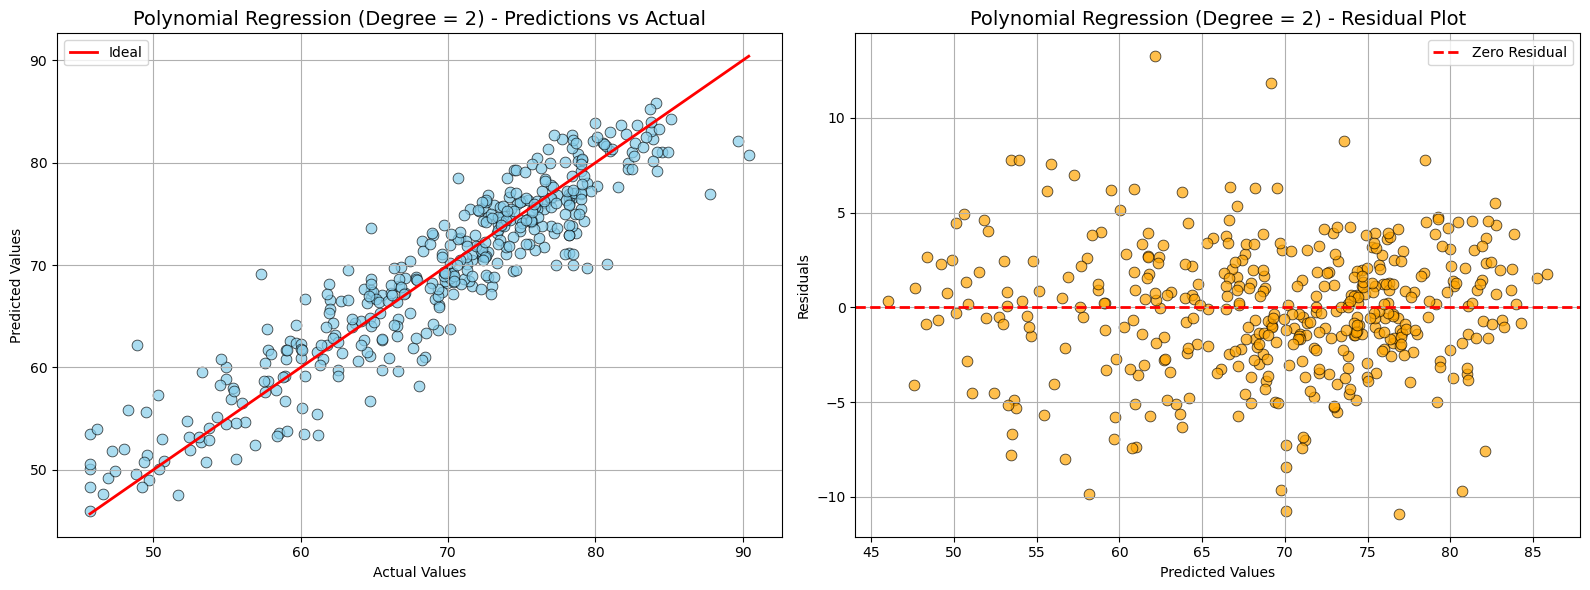

In [140]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["Polynomial2Regression"]["y_pred"],
    model_name="Polynomial Regression (Degree = 2)",
);

#### 4.2.2) Polynomial Regression (Degree = 3)


In [141]:
filepath = "./saved_models/PolynomialRegression(Degree=3).joblib"

if os.path.exists(filepath):
    all_model_results["Polynomial3Regression"] = load_and_show_model_info(
        filepath, "Polynomial Regression (Degree = 3)"
    )
else:
    poly = PolynomialFeatures(degree=3)
    x_train_poly3 = poly.fit_transform(x_train_scaled)
    x_test_poly3 = poly.transform(x_test_scaled)

    # Scale data again after transforming to polynomial features
    scaler = StandardScaler()
    x_train_poly3 = scaler.fit_transform(x_train_poly3)
    x_test_poly3 = scaler.transform(x_test_poly3)

    poly3_model = LinearRegression()

    all_model_results["Polynomial3Regression"] = train_and_evaluate_model(
        model=poly3_model,
        x_train=x_train_poly3,
        y_train=y_train,
        x_test=x_test_poly3,
        y_test=y_test,
        model_name="Polynomial Regression (Degree = 3)",
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/PolynomialRegression(Degree=3).joblib
+-----------------------------------------------------------------------------+
|           POLYNOMIAL REGRESSION (DEGREE = 3) - EVALUATION RESULTS           |
+-----------------------------------------------------------------------------+
Train R² Score                     : 0.9362
R² Score                           : 0.8076
Mean Absolute Error (MAE)          : 3.0091
Mean Squared Error (MSE)           : 16.6172
Root Mean Squared Error (RMSE)     : 4.0764


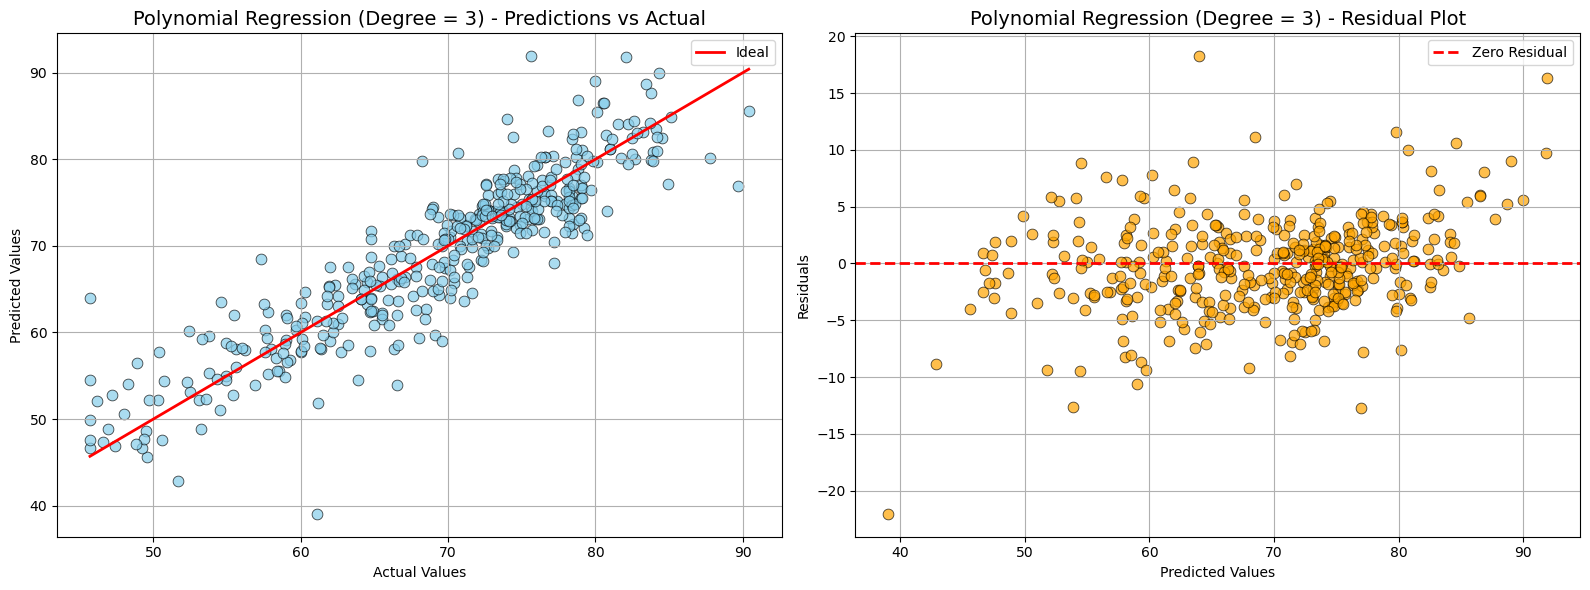

In [142]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["Polynomial3Regression"]["y_pred"],
    model_name="Polynomial Regression (Degree = 3)",
);

### 4.3) Lasso Regression



In [143]:
filepath = "./saved_models/Lasso.joblib"

if os.path.exists(filepath):
    all_model_results["Lasso"] = load_and_show_model_info(
        filepath, "Lasso", show_params=True
    )
else:
    lasso_model = Lasso(max_iter=1000)
    alphas = np.logspace(-4, 1, 40)  # Range from 0.0001 to 10
    params = {"alpha": alphas}

    all_model_results["Lasso"] = train_and_evaluate_model_gridsearch(
        model=lasso_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="Lasso",
        cv=cv,
        filepath=filepath,
        save=True,
    )


[INFO] Loading saved model from: ./saved_models/Lasso.joblib
+----------------------------------------------------------+
|           LASSO - GRIDSEARCHCV BEST PARAMETERS           |
+----------------------------------------------------------+
{'alpha': 0.027283333764867666}
+------------------------------------------------+
|           LASSO - EVALUATION RESULTS           |
+------------------------------------------------+
Train R² Score                     : 0.7883
R² Score                           : 0.7838
Mean Absolute Error (MAE)          : 3.3697
Mean Squared Error (MSE)           : 18.6758
Root Mean Squared Error (RMSE)     : 4.3216


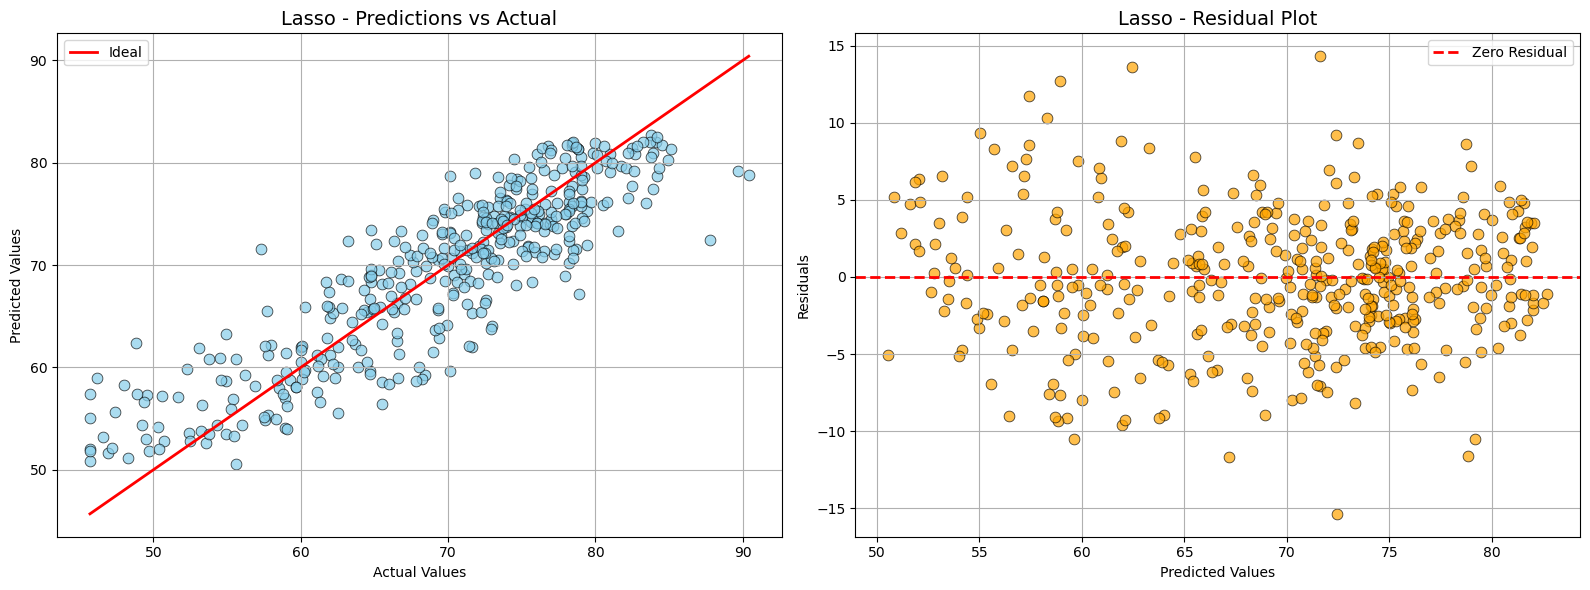

In [144]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["Lasso"]["y_pred"],
    model_name="Lasso",
);

In the graph below, we can observe that a higher alpha may cause the R² score to reduce and may lead to an underfitting situation, causing a significant drop in R².

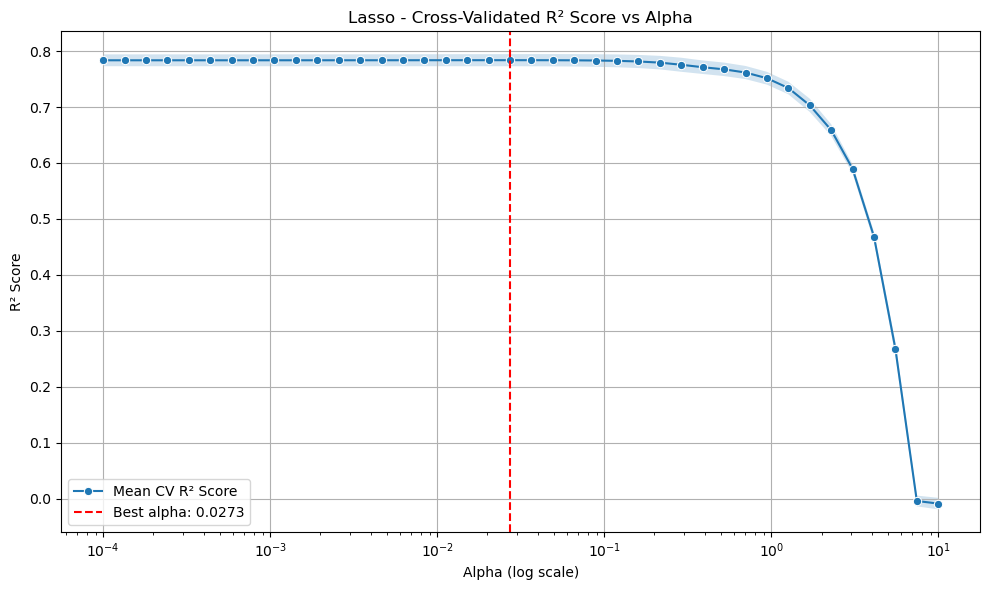

In [145]:
plot_alpha_vs_score(
    all_model_results["Lasso"]["cv_results"],
    all_model_results["Lasso"]["model"],
    "Lasso",
)

### 4.4) Ridge Regression

In [146]:
filepath = "./saved_models/Ridge.joblib"

if os.path.exists(filepath):
    all_model_results["Ridge"] = load_and_show_model_info(
        filepath, "Ridge", show_params=True
    )
else:
    ridge_model = Ridge(max_iter=1000)

    alphas = np.logspace(-4, 1, 40)  # From 0.0001 to 10
    params = {"alpha": alphas}

    all_model_results["Ridge"] = train_and_evaluate_model_gridsearch(
        model=ridge_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="Ridge",
        cv=cv,
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/Ridge.joblib
+----------------------------------------------------------+
|           RIDGE - GRIDSEARCHCV BEST PARAMETERS           |
+----------------------------------------------------------+
{'alpha': 5.541020330009481}
+------------------------------------------------+
|           RIDGE - EVALUATION RESULTS           |
+------------------------------------------------+
Train R² Score                     : 0.7884
R² Score                           : 0.7838
Mean Absolute Error (MAE)          : 3.3709
Mean Squared Error (MSE)           : 18.6773
Root Mean Squared Error (RMSE)     : 4.3217


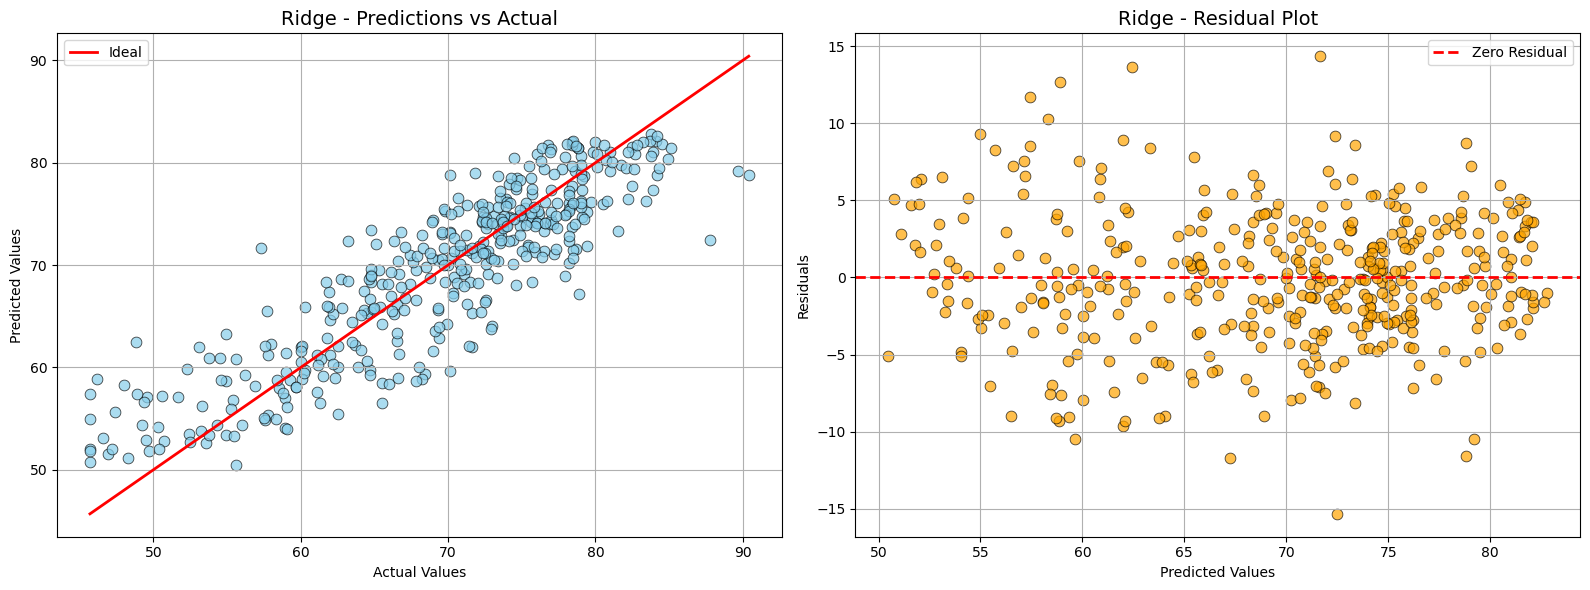

In [147]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["Ridge"]["y_pred"],
    model_name="Ridge",
);

The plot below represents the cross-validated R² score across the different alphas for the `Ridge` model. The graph demonstrates that the `Ridge`'s performance remains stable when the alpha changes. This indicates that the `Ridge` is less sensitive to alpha in this case.

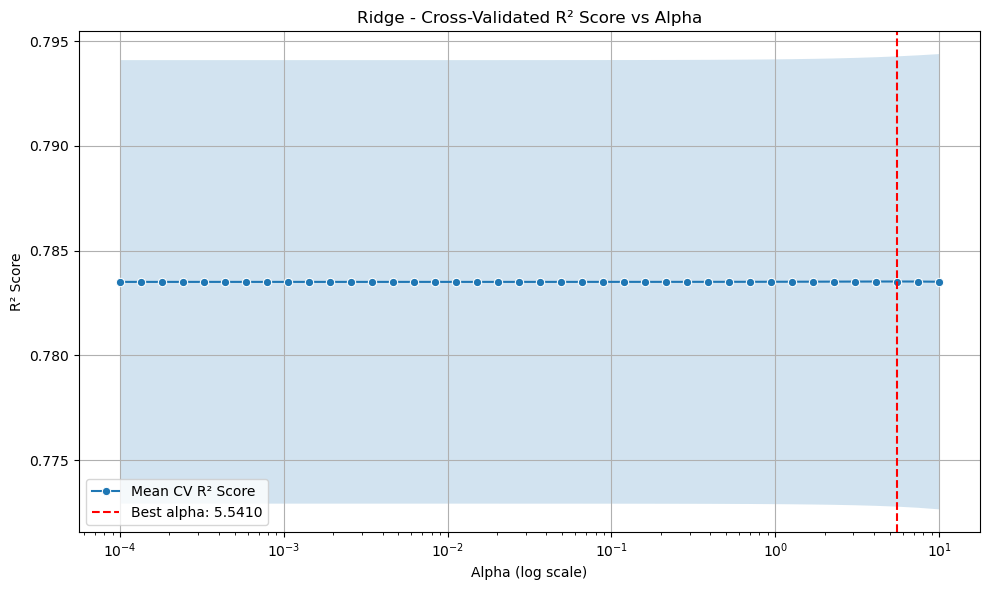

In [148]:
plot_alpha_vs_score(
    all_model_results["Ridge"]["cv_results"],
    all_model_results["Ridge"]["model"],
    "Ridge",
)

### 4.5) Decision Tree

In [174]:
filepath = "./saved_models/DecisionTree.joblib"

if os.path.exists(filepath):
    all_model_results["DecisionTree"] = load_and_show_model_info(
        filepath, "Decision Tree", show_params=True
    )
else:
    decision_tree_model = DecisionTreeRegressor(random_state=19)

    params = {
        "max_depth": np.arange(2, 24, 2),
        "min_samples_split": np.arange(2, 10, 2),
        "min_samples_leaf": [1, 2, 4, 6],
        "max_features": ["sqrt", "log2", None],
        "criterion": ["squared_error", "absolute_error"],
    }

    all_model_results["DecisionTree"] = train_and_evaluate_model_gridsearch(
        model=decision_tree_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="Decision Tree",
        cv=cv,
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/DecisionTree.joblib
+------------------------------------------------------------------+
|           DECISION TREE - GRIDSEARCHCV BEST PARAMETERS           |
+------------------------------------------------------------------+
{'criterion': 'absolute_error', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 2}
+--------------------------------------------------------+
|           DECISION TREE - EVALUATION RESULTS           |
+--------------------------------------------------------+
Train R² Score                     : 0.9281
R² Score                           : 0.8283
Mean Absolute Error (MAE)          : 2.8300
Mean Squared Error (MSE)           : 14.8324
Root Mean Squared Error (RMSE)     : 3.8513


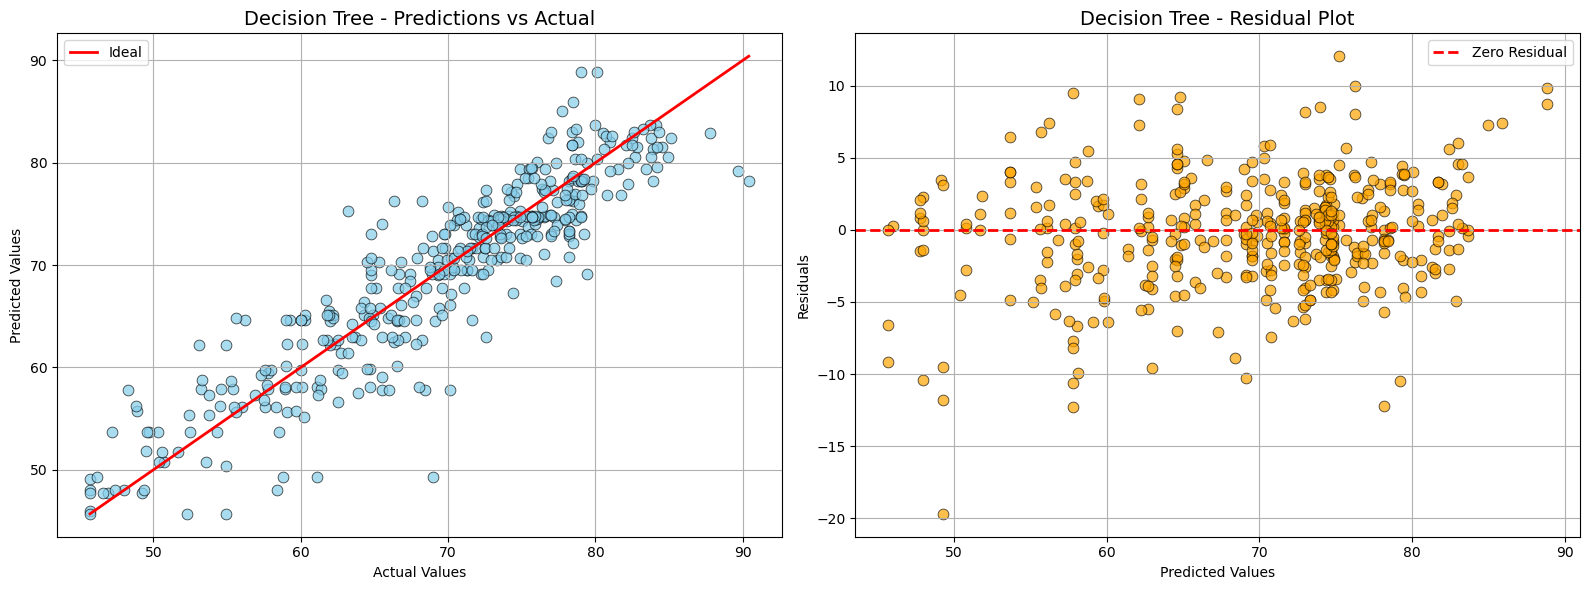

In [175]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["DecisionTree"]["y_pred"],
    model_name="Decision Tree",
);

### 4.6) Random Forest


In [151]:
filepath = "./saved_models/RandomForest.joblib"

if os.path.exists(filepath):
    all_model_results["RandomForest"] = load_and_show_model_info(
        filepath, "Random Forest", show_params=True
    )
else:
    random_forest_model = RandomForestRegressor(random_state=random_state)

    params = {
        "n_estimators": [50, 100, 200],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
        "bootstrap": [True, False],
    }

    all_model_results["RandomForest"] = train_and_evaluate_model_gridsearch(
        model=random_forest_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="Random Forest",
        cv=cv,
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/RandomForest.joblib
+------------------------------------------------------------------+
|           RANDOM FOREST - GRIDSEARCHCV BEST PARAMETERS           |
+------------------------------------------------------------------+
{'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
+--------------------------------------------------------+
|           RANDOM FOREST - EVALUATION RESULTS           |
+--------------------------------------------------------+
Train R² Score                     : 0.9931
R² Score                           : 0.9014
Mean Absolute Error (MAE)          : 2.2594
Mean Squared Error (MSE)           : 8.5211
Root Mean Squared Error (RMSE)     : 2.9191


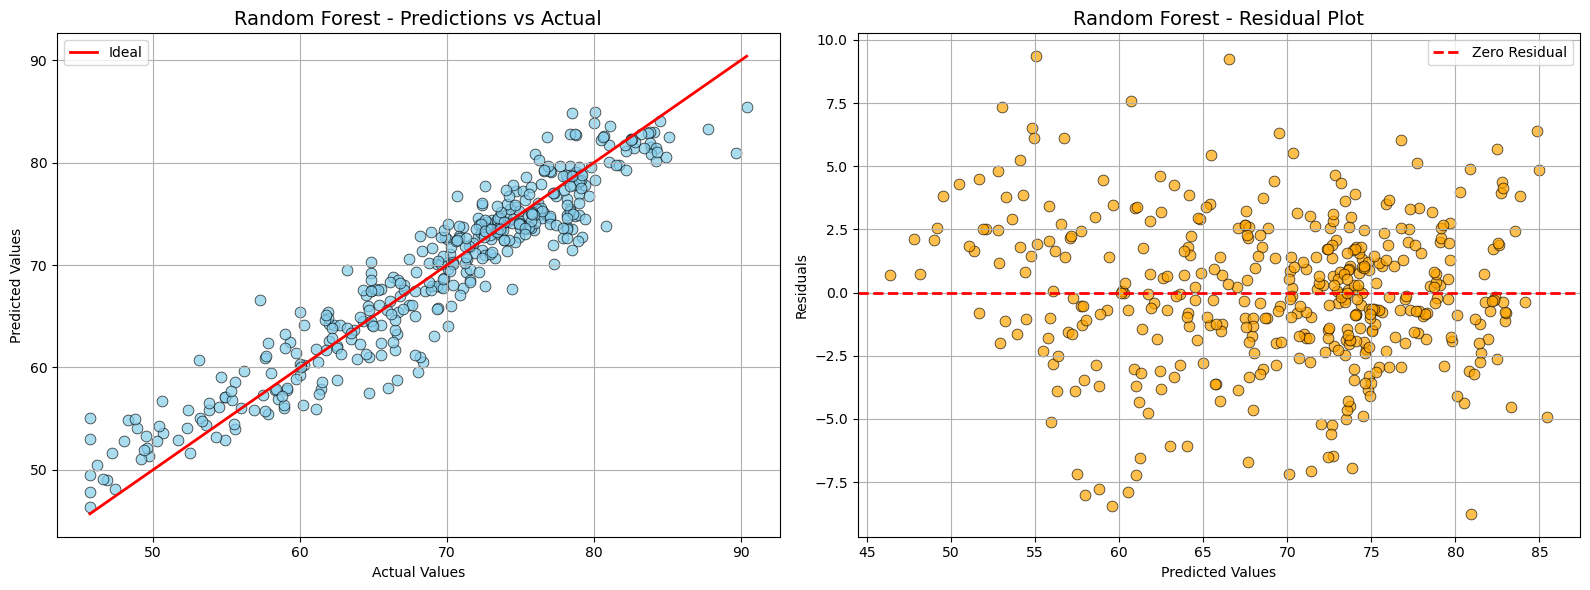

In [152]:
visualize_model_predictions(
    y_test, all_model_results["RandomForest"]["y_pred"], model_name="Random Forest"
);

### 4.7) XGBoost

In [153]:
filepath = "./saved_models/XGBoost.joblib"

if os.path.exists(filepath):
    all_model_results["XGBoost"] = load_and_show_model_info(
        filepath, "XGBoost", show_params=True
    )
else:
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=random_state,
        verbosity=0,
        n_jobs=-1,
    )

    params = {
        "n_estimators": [100, 200],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.1, 0.3],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
    }

    all_model_results["XGBoost"] = train_and_evaluate_model_gridsearch(
        model=xgb_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="XGBoost",
        cv=cv,
        filepath=filepath,
        save=True,
    )

[INFO] Loading saved model from: ./saved_models/XGBoost.joblib
+------------------------------------------------------------+
|           XGBOOST - GRIDSEARCHCV BEST PARAMETERS           |
+------------------------------------------------------------+
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
+--------------------------------------------------+
|           XGBOOST - EVALUATION RESULTS           |
+--------------------------------------------------+
Train R² Score                     : 0.9845
R² Score                           : 0.8994
Mean Absolute Error (MAE)          : 2.2839
Mean Squared Error (MSE)           : 8.6885
Root Mean Squared Error (RMSE)     : 2.9476


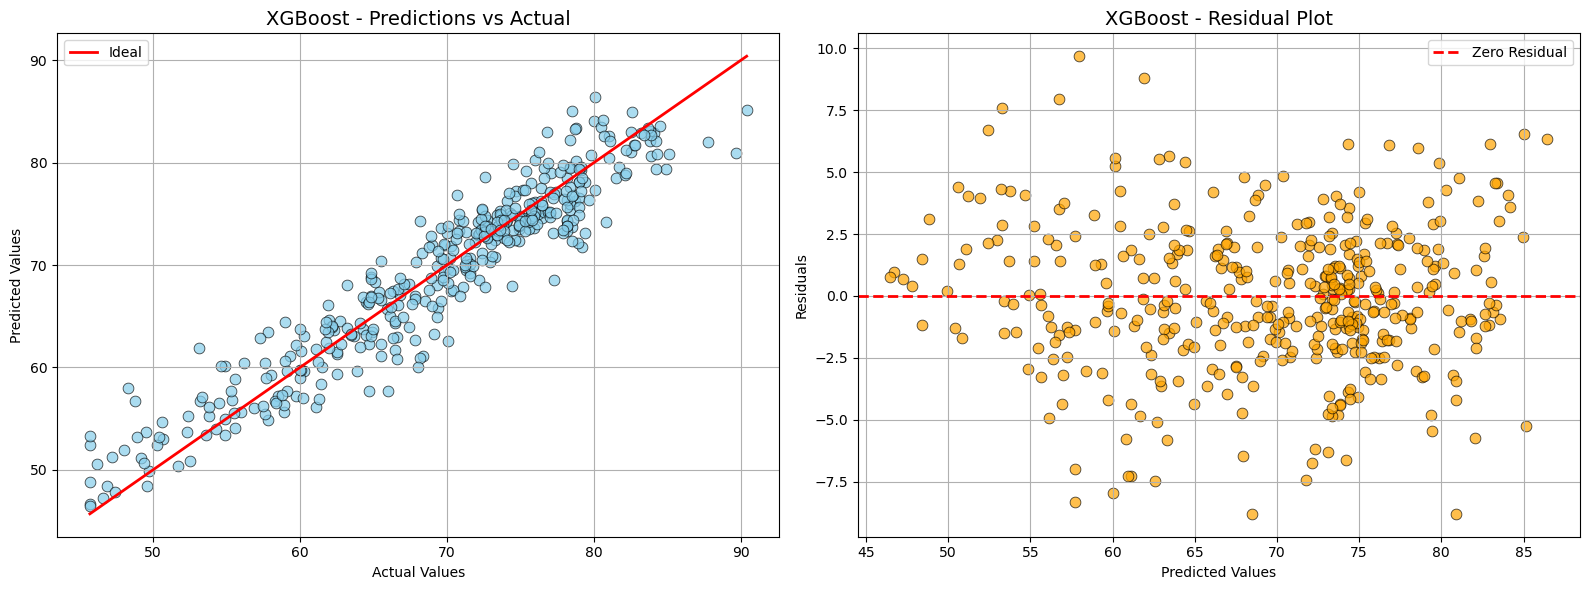

In [154]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["XGBoost"]["y_pred"],
    model_name="XGBoost",
);

### 4.8) K-Nearest Neighbors Regression

In [155]:
filepath = "./saved_models/KNN.joblib"

if os.path.exists(filepath):
    all_model_results["KNN"] = load_and_show_model_info(
        filepath, "KNN", show_params=True
    )
else:
    knn_model = KNeighborsRegressor()

    params = {
        "n_neighbors": [3, 5, 7, 9],  # number of neighbors
        "weights": [
            "uniform",
            "distance",
        ],  # uniform = equal weight, distance = closer has more weight
        "p": [1, 2],  # 1 = Manhattan distance, 2 = Euclidean distance
        "algorithm": ["auto", "ball_tree", "kd_tree"],
    }

    all_model_results["KNN"] = train_and_evaluate_model_gridsearch(
        model=knn_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="KNN",
        cv=cv,
        save=True,
        filepath=filepath,
    )

[INFO] Loading saved model from: ./saved_models/KNN.joblib
+--------------------------------------------------------+
|           KNN - GRIDSEARCHCV BEST PARAMETERS           |
+--------------------------------------------------------+
{'algorithm': 'auto', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
+----------------------------------------------+
|           KNN - EVALUATION RESULTS           |
+----------------------------------------------+
Train R² Score                     : 1.0000
R² Score                           : 0.8679
Mean Absolute Error (MAE)          : 2.5737
Mean Squared Error (MSE)           : 11.4076
Root Mean Squared Error (RMSE)     : 3.3775


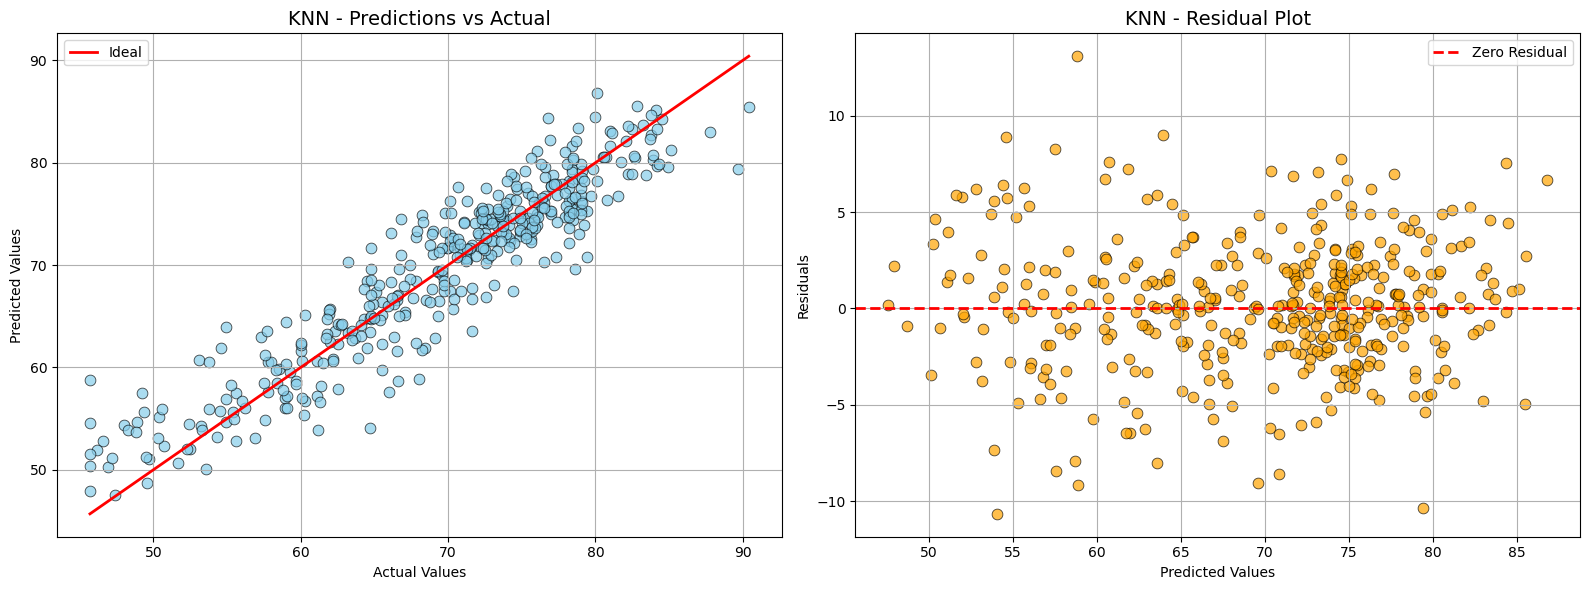

In [156]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["KNN"]["y_pred"],
    model_name="KNN",
);

### 4.9) SVR (Support Vector Regressor)

In [157]:
filepath = "./saved_models/SVR.joblib"

if os.path.exists(filepath):
    all_model_results["SVR"] = load_and_show_model_info(
        filepath, "SVR", show_params=True
    )
else:
    svr_model = SVR()

    params = {
        "C": [0.1, 1, 10],
        "epsilon": [0.1, 0.2, 0.5],
        "gamma": ["scale", "auto"],
    }

    all_model_results["SVR"] = train_and_evaluate_model_gridsearch(
        model=svr_model,
        param_grid=params,
        x_train=x_train_scaled,
        y_train=y_train,
        x_test=x_test_scaled,
        y_test=y_test,
        model_name="SVR",
        cv=cv,
        save=True,
        filepath=filepath,
    )



[INFO] Loading saved model from: ./saved_models/SVR.joblib
+--------------------------------------------------------+
|           SVR - GRIDSEARCHCV BEST PARAMETERS           |
+--------------------------------------------------------+
{'C': 10, 'epsilon': 0.5, 'gamma': 'auto'}
+----------------------------------------------+
|           SVR - EVALUATION RESULTS           |
+----------------------------------------------+
Train R² Score                     : 0.9216
R² Score                           : 0.8665
Mean Absolute Error (MAE)          : 2.6433
Mean Squared Error (MSE)           : 11.5342
Root Mean Squared Error (RMSE)     : 3.3962


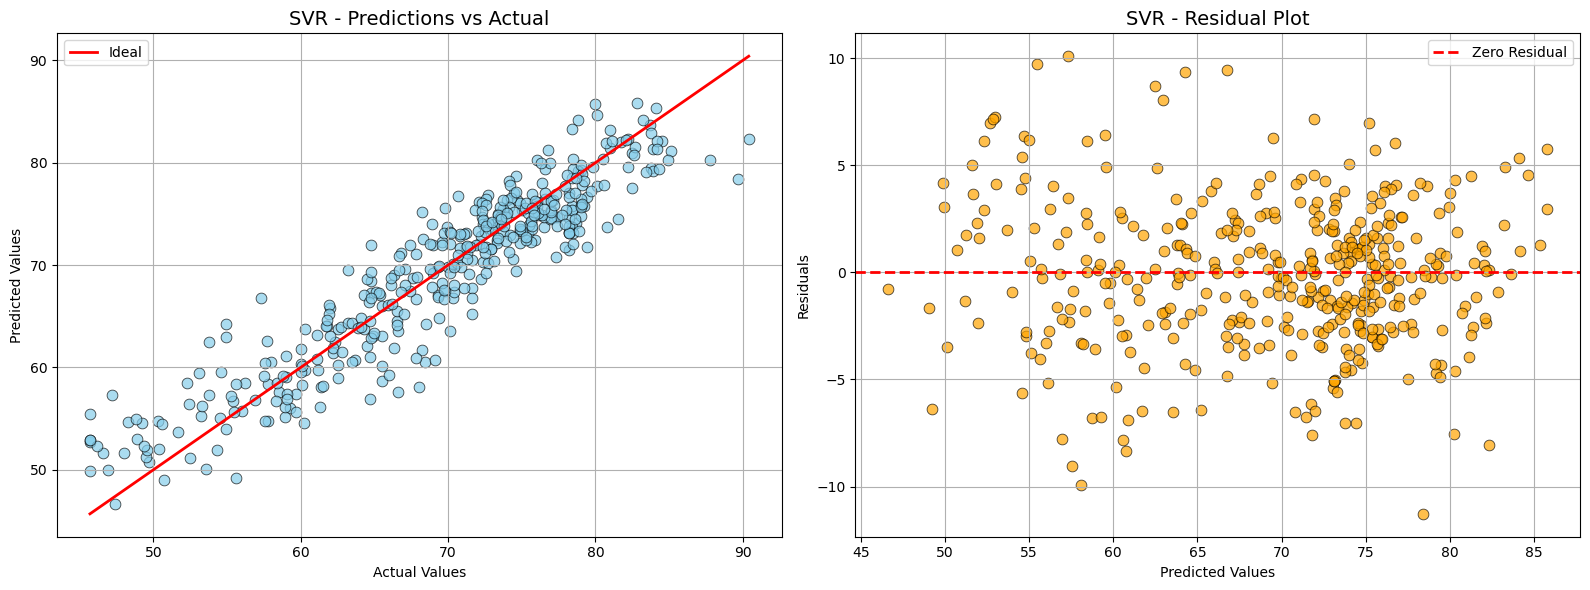

In [158]:
visualize_model_predictions(
    y_true=y_test,
    y_pred=all_model_results["SVR"]["y_pred"],
    model_name="SVR",
);

# VII. BEST MODEL SELECTION

## 1) Helper Function

The `plot_model_comparison` creates four bar charts to visualize the score of all models. 

In [159]:
def plot_model_comparison(results, metrics=["r2_score", "rmse", "mae", "mse"]):
    for metric in metrics:
        plt.figure(figsize=(12, 6))
        score_list = []

        for model_name, result in results.items():
            if metric in result:
                score_list.append((model_name, result[metric]))

        # Sorting `score_list`
        if metric == "r2_score":
            score_list.sort(
                key=lambda x: x[1], reverse=True
            )  # High to low (high is better)
        else:
            score_list.sort(key=lambda x: x[1])  # Low to high (low is better)

        model_names = [x[0] for x in score_list]
        scores = [x[1] for x in score_list]

        # Create DataFrame
        data = {"Model": model_names, metric.upper(): scores}

        ax = sns.barplot(
            x="Model",
            y=metric.upper(),
            data=data,
            palette="Blues_d",
            hue="Model",
            legend=False,
        )

        # Add text labels to the top of bar chart
        for i, v in enumerate(scores):
            ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

        plt.title(f"{metric.upper()} Comparison Across Models", fontsize=16)
        plt.ylabel(metric.upper(), fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

## 2) Best model selection

In [160]:
selected_columns = ["r2_train", "r2_score", "mae", "mse", "rmse"]

# Convert the dictionary to a DataFrame and transpose it
results_df = pd.DataFrame(all_model_results).T

# Only include the `selected_columns``
results_df = results_df[selected_columns]

# Convert columns to numeric, coerce errors to NaN
for col in selected_columns:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

# Round the numerical data to .4
results_df = results_df.round(4)

# Save to file
results_df.to_csv("./saved_scores/model_comparison_summary.csv", index=False)

results_df

,r2_train,r2_score,mae,mse,rmse
LinearRegression,0.7884,0.7835,3.3727,18.7031,4.3247
Polynomial2Regression,0.8784,0.8676,2.5910,11.4385,3.3821
Polynomial3Regression,0.9362,0.8076,3.0091,16.6172,4.0764
Lasso,0.7883,0.7838,3.3697,18.6758,4.3216
Ridge,0.7884,0.7838,3.3709,18.6773,4.3217
DecisionTree,0.9281,0.8283,2.8300,14.8324,3.8513
RandomForest,0.9931,0.9014,2.2594,8.5211,2.9191
XGBoost,0.9845,0.8994,2.2839,8.6885,2.9476
KNN,1.0000,0.8679,2.5737,11.4076,3.3775
SVR,0.9216,0.8665,2.6433,11.5342,3.3962


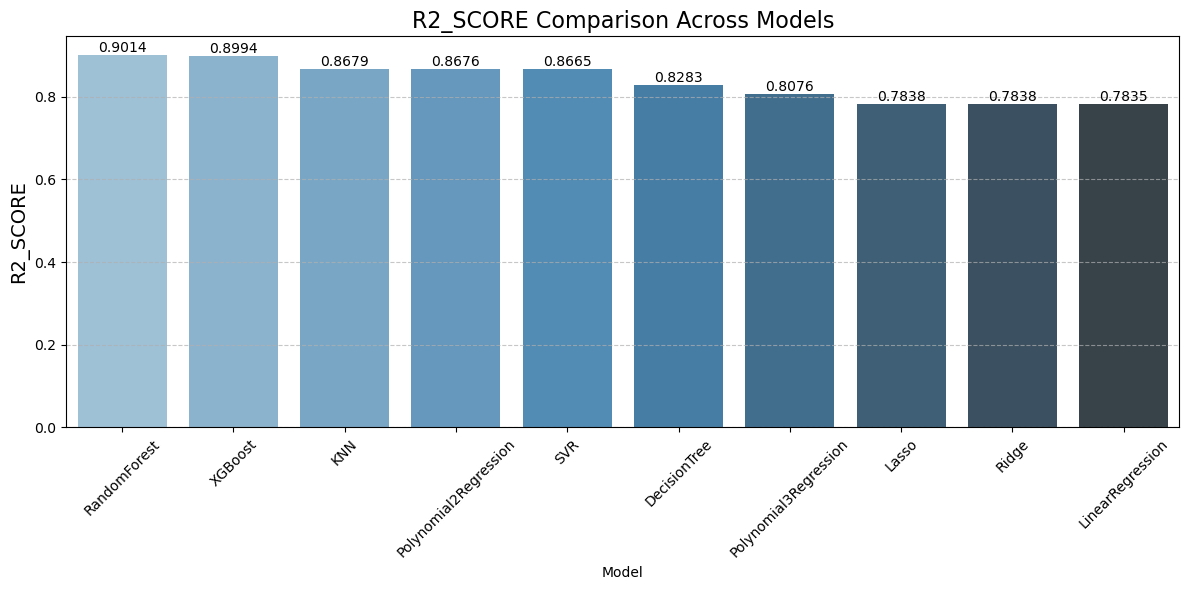

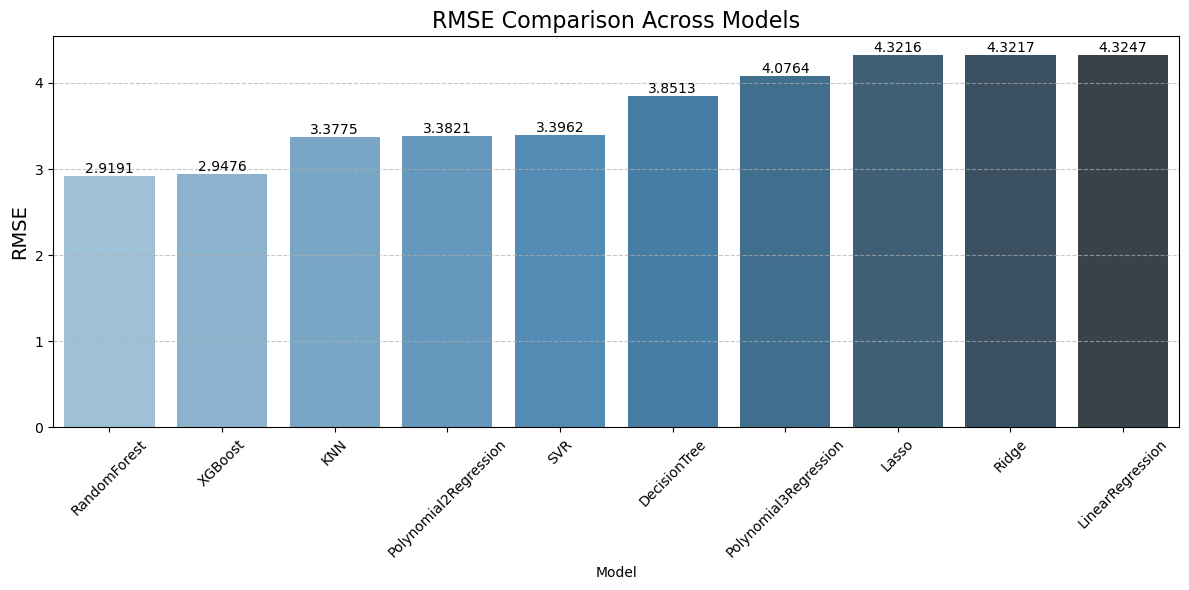

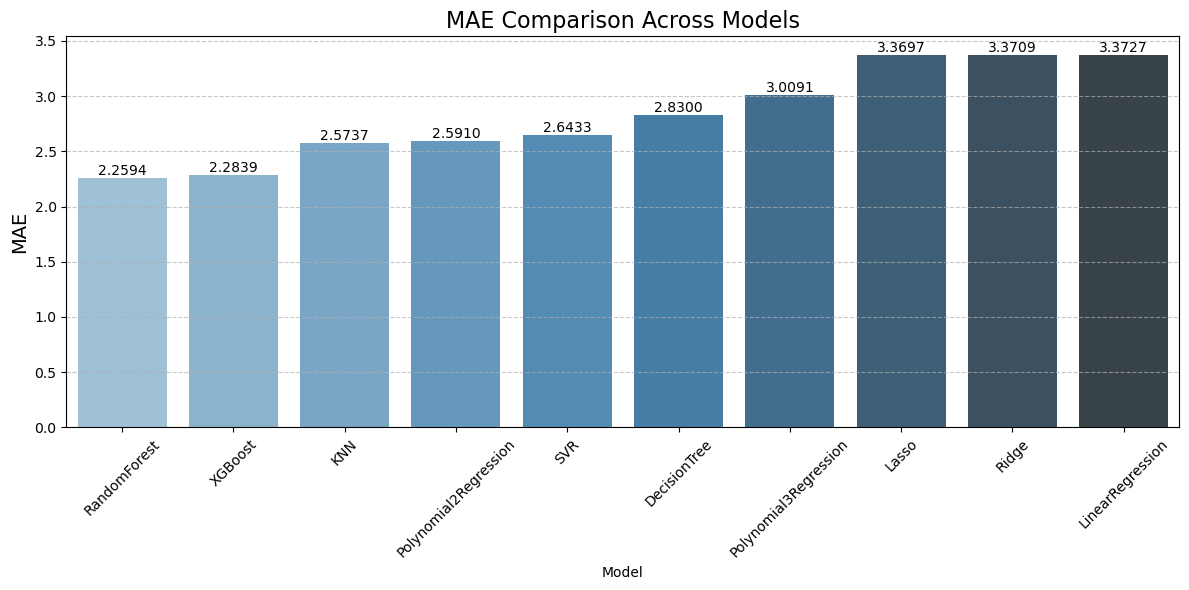

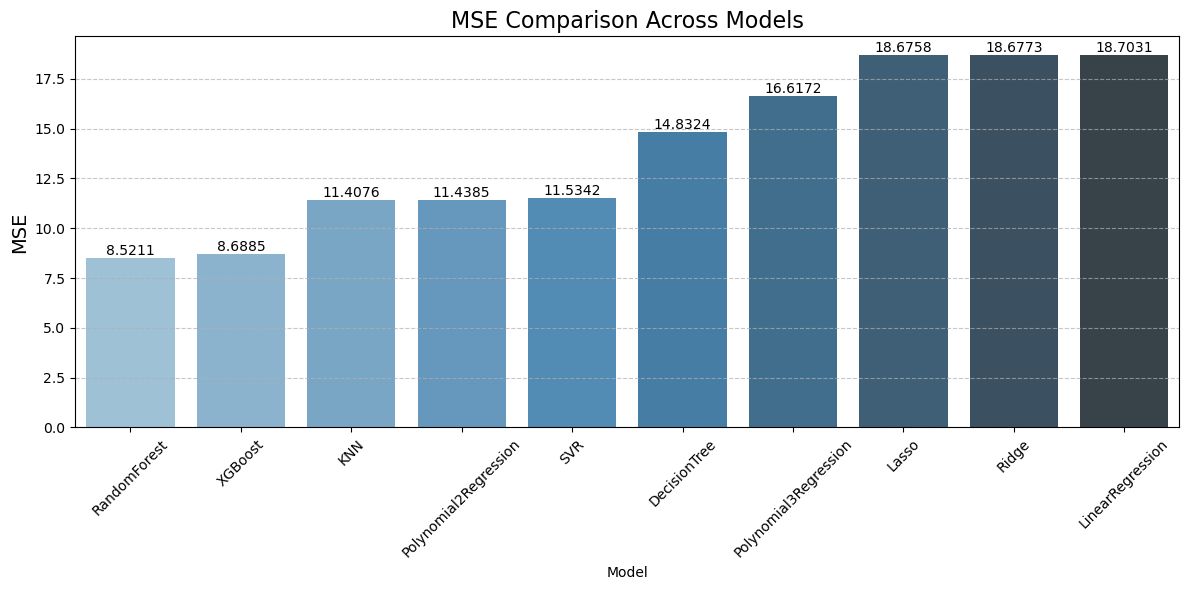

In [161]:
plot_model_comparison(all_model_results)

After evaluating multiple machine learning models for life expectancy prediction, the two with the highest scores are `Random Forest` and `XGBoost` across the evaluation metrics. The best model is chosen based on its interpretability, computational efficiency, and theoretical fit to the given dataset.

| Metric                            | Random Forest     | XGBoost      |
|-----------------------------------|-------------------|--------------|
| R² Train Score                    | **0.9931**        | 0.9845       |
| R² Score                          | **0.9014**        | 0.8994       |
| Mean Absolute Error (MAE)         | **2.2594**        | 2.2839       |
| Mean Squared Error (MSE)          | **8.5211**        | 8.6885       |
| Root Mean Squared Error (RMSE)    | **2.9191**        | 2.9476       |


**Suitability for Small Dataset**

This life expectancy dataset has around 2,000 rows, which makes Random Forest a suitable model more than XGBoost for a few reasons: 
- Random Forest can perform well on small-to-medium datasets, without requiring large-scale data or complex regularization. 
- On the other hand, XGBoost, a powerful model, works best on larger datasets because of its advanced regularization, which is better able to capture nuances in big data.
- In a small dataset like this, the added complexity of XGBoost may not translate into meaning-ful performance gains.

**Over-fitting problems**

Both models still show signs of overfitting because of the gap in training and validation scores. 

- Although Random Forest performs the high training R2 (~0.99), its generalization gap is still acceptable, with a strong validation R² score of ~0.90. This indicates minimal overfitting, especially given the low error metrics.
- In contrast, XGBoost also had a high training R2 score (~0.98) and validation R2 score (~0.89). However, its slightly higher in other metrics makes it may be more sensitive to over-fitting in this context. 

In conclusion, the final model that predicts the `test.csv` dataset is `Random Forest`, which has numerous benefits. It is the most appropriate model for this dataset as it balances predictive performance, generalization ability, and real-world applicability.

In [162]:
best_model = all_model_results["RandomForest"]["model"]

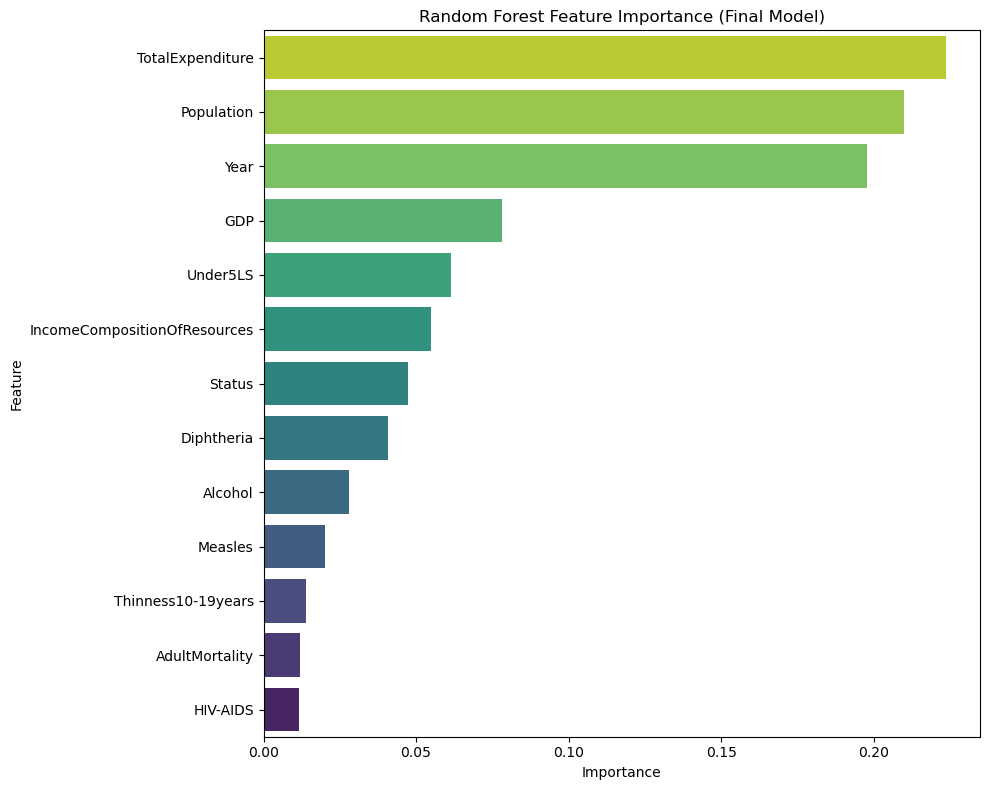

In [163]:
feature_names = selected_df.drop("TARGET_LifeExpectancy", axis=1).columns
important_feat = best_model.feature_importances_

feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": important_feat}
).sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_imp_df,
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature",
    dodge=False,
    legend=False,
)

plt.title("Random Forest Feature Importance (Final Model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# VIII. PREDICTION WITH BEST MODEL

## 1) Load dataset

In [164]:
test_df = pd.read_csv('./inputs/test.csv')

test_df

,ID,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness1-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
0,1,120,2017,0,335,314,356,66,6.35,0.000000,...,7.0,3.84,64,1.9,4139.29,2785935.0,8.3,8.2,0.531,3.376389
1,2,120,2016,0,348,338,358,67,8.33,23.965612,...,68.0,3.31,64,2.0,536.83,2692466.0,8.5,8.3,0.527,3.376389
2,3,120,2015,0,355,362,348,69,8.10,35.958573,...,67.0,4.26,77,2.3,542.77,2599834.0,8.6,8.5,0.523,3.376389
3,4,120,2014,0,358,348,368,72,8.24,256.122524,...,75.0,3.30,75,2.6,5150.04,259615.0,8.8,8.6,0.508,3.209361
4,5,120,2013,0,361,368,354,75,8.06,239.891392,...,73.0,3.38,71,2.5,4815.02,24218565.0,8.9,8.8,0.495,3.065942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,863,155,2006,0,723,668,778,27,4.36,0.000000,...,67.0,7.13,65,33.6,508.89,12777511.0,9.4,9.4,0.407,3.033150
863,864,155,2005,0,715,742,688,26,4.06,0.000000,...,7.0,6.52,68,36.7,507.75,12633897.0,9.8,9.9,0.418,3.082207
864,865,155,2004,0,73,72,74,25,4.43,0.000000,...,73.0,6.53,71,39.8,64.23,125525.0,1.2,1.3,0.427,3.162278
865,866,155,2003,0,686,672,700,25,1.72,0.000000,...,76.0,6.16,75,42.1,614.42,12366165.0,1.6,1.7,0.427,3.130495


## 2) Rename Thinness1-19years

In [165]:
test_df.rename(columns={"Thinness1-19years": "Thinness10-19years"}, inplace=True)

In [166]:
test_df.describe()

,ID,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
count,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,...,867.000000,867.000000,867.000000,867.000000,867.000000,8.670000e+02,867.000000,867.000000,867.000000,867.000000
mean,434.000000,97.908881,2009.519031,0.147636,168.310265,167.351788,169.268743,23.673587,4.323230,675.455038,...,81.675894,5.926228,80.869666,2.002999,6768.605686,4.977211e+06,4.458247,4.474740,0.638852,3.444089
std,250.425638,59.047382,4.615772,0.354943,136.148089,136.339678,136.521130,54.762901,3.624657,1742.603943,...,24.150902,2.287944,25.153943,5.716692,14405.688854,1.069932e+07,3.614439,3.704803,0.185802,0.538432
min,1.000000,1.000000,2002.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.010000,0.000000,...,3.000000,1.120000,3.000000,0.100000,4.130000,1.350000e+02,0.100000,0.100000,0.000000,0.000000
25%,217.500000,41.000000,2006.000000,0.000000,71.000000,68.000000,72.000000,0.000000,1.155000,2.005443,...,78.500000,4.325000,78.000000,0.100000,413.730000,1.274450e+05,1.400000,1.400000,0.483000,3.154352
50%,434.000000,104.000000,2010.000000,0.000000,143.000000,140.000000,144.000000,2.000000,3.240000,60.341451,...,92.000000,5.830000,91.000000,0.100000,1272.850000,3.331430e+05,3.500000,3.400000,0.677000,3.535534
75%,650.500000,155.000000,2014.000000,0.000000,224.000000,223.000000,226.000000,23.500000,7.435000,466.703840,...,97.000000,7.500000,97.000000,0.600000,4755.220000,3.253793e+06,6.800000,6.700000,0.778500,3.781534
max,867.000000,191.000000,2017.000000,1.000000,723.000000,742.000000,778.000000,490.000000,13.200000,11734.853810,...,99.000000,11.790000,99.000000,43.500000,99192.600000,5.414673e+07,16.300000,19.100000,0.937000,4.549725


In [167]:
columns_to_drop = [
    "ID",
    "BMI",
    "AdultMortality-Male",
    "AdultMortality-Female",
    "SLS",
    "Polio",
    "PercentageExpenditure",
    "Thinness5-9years",
    "Schooling",
    "Country",
]

x_test_real = test_df.drop(columns=columns_to_drop)

## 3) Scale Test Dataset

In [168]:
exclude_cols = ["Year", "Status"]

x_test_real_scaled_part = x_test_real.drop(columns=exclude_cols)

# Load the standard scaler from file
std_scaler = joblib.load("./saved_scalers/standard_scaler.joblib")

x_test_real_scaled = std_scaler.transform(x_test_real_scaled_part)
x_test_real_scaled = pd.DataFrame(
    x_test_real_scaled, columns=x_test_real_scaled_part.columns, index=x_test_real.index
)

# Add the excluded columns back to the x
x_test_real_scaled = pd.concat([x_test_real_scaled, x_test_real[exclude_cols]], axis=1)

In [169]:
x_test_real_scaled.describe()

,AdultMortality,Alcohol,Measles,Under5LS,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,IncomeCompositionOfResources,Year,Status
count,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000
mean,-0.003313,-0.078674,7.216246,-0.146111,0.044652,-0.280115,2.193492,0.654971,0.349754,-0.059528,0.082252,2009.519031,0.147636
std,1.288029,0.866436,35.655448,1.908113,0.948666,1.599401,8.503881,3.162959,2.308105,0.913518,1.024971,4.615772,0.354943
min,-1.586152,-1.109706,-0.677664,-1.019114,-1.948187,-5.231419,-0.637319,-0.830259,-0.723924,-1.161037,-3.441958,2002.000000,0.000000
25%,-0.923917,-0.836006,-0.677664,-1.019114,-0.619276,-0.462581,-0.637319,-0.740326,-0.696460,-0.832473,-0.777503,2006.000000,0.000000
50%,-0.242761,-0.337609,-0.645527,-0.939360,0.004753,0.364017,-0.637319,-0.551695,-0.652086,-0.301716,0.292693,2010.000000,0.000000
75%,0.523539,0.665161,-0.076936,-0.234864,0.697196,0.745524,0.106458,0.212906,-0.022030,0.532330,0.852614,2014.000000,0.000000
max,5.244329,2.043223,450.449479,15.144397,2.475988,0.872693,63.922470,20.947879,10.956825,2.933373,1.726975,2017.000000,1.000000


## 4) Predict The Test Set

In [170]:
y_real_pred = best_model.predict(x_test_real_scaled)

In [171]:
test_df

,ID,Country,Year,Status,AdultMortality,AdultMortality-Male,AdultMortality-Female,SLS,Alcohol,PercentageExpenditure,...,Polio,TotalExpenditure,Diphtheria,HIV-AIDS,GDP,Population,Thinness10-19years,Thinness5-9years,IncomeCompositionOfResources,Schooling
0,1,120,2017,0,335,314,356,66,6.35,0.000000,...,7.0,3.84,64,1.9,4139.29,2785935.0,8.3,8.2,0.531,3.376389
1,2,120,2016,0,348,338,358,67,8.33,23.965612,...,68.0,3.31,64,2.0,536.83,2692466.0,8.5,8.3,0.527,3.376389
2,3,120,2015,0,355,362,348,69,8.10,35.958573,...,67.0,4.26,77,2.3,542.77,2599834.0,8.6,8.5,0.523,3.376389
3,4,120,2014,0,358,348,368,72,8.24,256.122524,...,75.0,3.30,75,2.6,5150.04,259615.0,8.8,8.6,0.508,3.209361
4,5,120,2013,0,361,368,354,75,8.06,239.891392,...,73.0,3.38,71,2.5,4815.02,24218565.0,8.9,8.8,0.495,3.065942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,863,155,2006,0,723,668,778,27,4.36,0.000000,...,67.0,7.13,65,33.6,508.89,12777511.0,9.4,9.4,0.407,3.033150
863,864,155,2005,0,715,742,688,26,4.06,0.000000,...,7.0,6.52,68,36.7,507.75,12633897.0,9.8,9.9,0.418,3.082207
864,865,155,2004,0,73,72,74,25,4.43,0.000000,...,73.0,6.53,71,39.8,64.23,125525.0,1.2,1.3,0.427,3.162278
865,866,155,2003,0,686,672,700,25,1.72,0.000000,...,76.0,6.16,75,42.1,614.42,12366165.0,1.6,1.7,0.427,3.130495


## 5) Save The Predictions To File

In [ ]:
final_predictions = pd.DataFrame(
    {"ID": test_df["ID"], "TARGET_LifeExpectancy": y_real_pred}
)

final_predictions.to_csv("./inputs/my_prediction.csv", index=False)

In [173]:
final_predictions

,ID,TARGET_LifeExpectancy
0,1,57.643083
1,2,56.658542
2,3,57.112542
3,4,56.431833
4,5,56.272792
...,...,...
862,863,49.901488
863,864,50.275000
864,865,55.535633
865,866,52.890042
